# Import các thư viện cần thiết

In [1]:
import numpy as np
import pandas as pd
import itertools
import time
import warnings
import os

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ks_2samp, levene

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer,
    OneHotEncoder, OrdinalEncoder, LabelEncoder
)

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score
)

from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, mutual_info_classif, RFECV
)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import (
    mean_squared_error, classification_report, roc_auc_score,
    f1_score, precision_score, recall_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore')

In [2]:
# df = pd.read_csv("hotel_bookings.csv")
df = pd.read_csv("../data/raw/hotel_bookings.csv")
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# **2.2.3. Các kỹ thuật tiền xử lý và đánh giá định lượng**

## **a) Xử lý giá trị thiếu có kiểm soát**

Để đánh giá khách quan hiệu quả của các phương pháp điền khuyết, nhóm thực hiện thực nghiệm có kiểm soát. Quy trình bao gồm việc chọn một thuộc tính số không có giá trị thiếu làm "Ground Truth", sau đó tạo nhân tạo **10% giá trị thiếu** theo cơ chế **MCAR** (Missing Completely At Random). Độ chính xác của việc điền khuyết được đo lường bằng chỉ số **RMSE**.

---

### **1. Các chiến lược điền khuyết**

#### **1.1. Điền khuyết đơn biến (Simple Imputation)**
Phương pháp này sử dụng các chỉ số thống kê mô tả của tập dữ liệu quan sát được $X_{obs} = \{x_1, x_2, ..., x_n\}$ để thay thế cho các giá trị thiếu $x_{miss}$.

*   **Mean (Trung bình):** Phù hợp với dữ liệu có phân phối chuẩn và ít ngoại lai.
  $$\hat{x}_{miss} = \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$
*   **Median (Trung vị):** Phù hợp với dữ liệu có phân phối lệch (skewed) hoặc chứa nhiều ngoại lai (outliers).
  $$\hat{x}_{miss} = \text{Giá trị tại vị trí } \frac{n+1}{2} \text{ sau khi sắp xếp chuỗi } X_{obs}$$
*   **Mode (Yếu vị):** Thường dùng cho dữ liệu phân loại hoặc dữ liệu số có tính chất rời rạc.
  $$\hat{x}_{miss} = \text{argmax}_{v \in \text{values}(X)} \sum_{i=1}^{n} \mathbb{I}(x_i = v)$$
  *(Trong đó $\mathbb{I}$ là hàm chỉ thị, trả về 1 nếu giá trị quan sát bằng $v$, ngược lại trả về 0)*.

#### **1.2. k-Nearest Neighbors (k-NN) Imputation**
Phương pháp đa biến này ước lượng giá trị thiếu dựa trên các quan sát (hàng xóm) tương đồng nhất trong không gian đặc trưng.
*   **Khoảng cách Euclidean:** Giữa bản ghi thiếu $u$ và bản ghi quan sát $v$ dựa trên $m$ thuộc tính:
  $$d(u, v) = \sqrt{\sum_{j=1}^{m} (u_j - v_j)^2}$$
*   **Giá trị ước lượng:** Được tính bằng trung bình (có thể có trọng số) của $k$ hàng xóm gần nhất:
  $$\hat{x}_u = \frac{1}{k} \sum_{i=1}^{k} x_i$$

#### **1.3. MICE (Multiple Imputation by Chained Equations)**
MICE là phương pháp điền khuyết đa biến mạnh mẽ, xem mỗi biến có giá trị thiếu là một hàm mục tiêu của các biến còn lại thông qua một chuỗi các mô hình hồi quy lặp lại.
*   **Mô hình hồi quy cho biến $X_j$:**
  $$X_j = f_j(X_{-j}, \beta_j) + \epsilon_j$$
  *Trong đó $X_{-j}$ đại diện cho tất cả các biến ngoại trừ $X_j$, và $\beta_j$ là các tham số của mô hình dự báo.*
*   **Quá trình lặp:** Quá trình dự báo được lặp lại qua nhiều chu kỳ (iterations) cho đến khi các giá trị điền khuyết đạt trạng thái hội tụ ổn định.

---

### **2. Chỉ số đánh giá: Root Mean Squared Error (RMSE)**

Để đo lường độ chính xác của quá trình điền khuyết, nhóm sử dụng sai số bình phương trung bình căn (RMSE) để so sánh giá trị điền khuyết ($\hat{y}_i$) với giá trị thực tế ban đầu ($y_i$):

$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$

**Nguyên tắc đánh giá:**
*   Giá trị **RMSE càng thấp** cho thấy phương pháp điền khuyết đó càng hiệu quả, giúp khôi phục dữ liệu gần nhất với trạng thái ban đầu.
*   Kết quả này là căn cứ để nhóm lựa chọn chiến lược điền khuyết tối ưu cho toàn bộ tập dữ liệu gốc.

---

In [4]:
# 1. Chuẩn bị dữ liệu đa biến (Multivariate Data)
# Chọn 'lead_time' làm mục tiêu và thêm các biến số có tương quan để thuật toán "học"
features = ['lead_time', 'adr', 'stays_in_week_nights', 'total_of_special_requests']
target_col = 'lead_time'

# Lấy một mẫu 5000 dòng và xóa các giá trị thiếu gốc để có "Ground Truth" hoàn hảo
df_experiment = df[features].dropna().sample(5000, random_state=42).reset_index(drop=True)
y_true = df_experiment[target_col].copy()

# 2. Tạo 10% giá trị thiếu nhân tạo (MCAR) CHỈ trên cột lead_time
np.random.seed(42)
n_missing = int(len(df_experiment) * 0.1)
missing_indices = np.random.choice(df_experiment.index, n_missing, replace=False)

df_missing = df_experiment.copy()
df_missing.loc[missing_indices, target_col] = np.nan

# 3. Hàm đánh giá RMSE (chỉ tính trên những ô bị làm thiếu)
def get_rmse(imputed_df, y_true, mask):
    # Lấy giá trị tại các vị trí bị thiếu sau khi đã điền khuyết
    y_pred = imputed_df.loc[mask, target_col]
    return np.sqrt(mean_squared_error(y_true[mask], y_pred))

results = []
mask = df_missing[target_col].isnull()

# --- Chiến lược 1, 2, 3: Mean, Median, Mode ---
for strategy in ['mean', 'median', 'most_frequent']:
    imputer = SimpleImputer(strategy=strategy)
    # Lưu ý: SimpleImputer trả về numpy array, cần chuyển lại DataFrame
    imputed_array = imputer.fit_transform(df_missing)
    imputed_df = pd.DataFrame(imputed_array, columns=features)

    rmse = get_rmse(imputed_df, y_true, mask)
    results.append({'Chiến lược': strategy.capitalize(), 'RMSE': rmse})

# --- Chiến lược 4: k-NN với k thuộc {3, 5, 10} ---
for k in [3, 5, 10]:
    knn_imputer = KNNImputer(n_neighbors=k)
    imputed_array = knn_imputer.fit_transform(df_missing)
    imputed_df = pd.DataFrame(imputed_array, columns=features)

    rmse = get_rmse(imputed_df, y_true, mask)
    results.append({'Chiến lược': f'k-NN (k={k})', 'RMSE': rmse})

# --- Chiến lược 5: MICE (Iterative Imputer) ---
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
imputed_array = mice_imputer.fit_transform(df_missing)
imputed_df = pd.DataFrame(imputed_array, columns=features)

rmse = get_rmse(imputed_df, y_true, mask)
results.append({'Chiến lược': 'MICE', 'RMSE': rmse})

# 4. Hiển thị bảng so sánh tổng hợp
df_comparison = pd.DataFrame(results).sort_values(by='RMSE')
print("BẢNG SO SÁNH HIỆU QUẢ ĐIỀN KHUYẾT ĐA BIẾN (RMSE):")
display(df_comparison)

# 5. Gợi ý lựa chọn tốt nhất
best_strategy = df_comparison.iloc[0]['Chiến lược']
print(f"\n=> Chiến lược tốt nhất dựa trên thực nghiệm là: {best_strategy}")

BẢNG SO SÁNH HIỆU QUẢ ĐIỀN KHUYẾT ĐA BIẾN (RMSE):


,Chiến lược,RMSE
5,k-NN (k=10),102.258417
4,k-NN (k=5),105.112947
6,MICE,106.889038
3,k-NN (k=3),107.415490
0,Mean,109.685384
1,Median,117.949735
2,Most_frequent,157.374293



=> Chiến lược tốt nhất dựa trên thực nghiệm là: k-NN (k=10)


### **Phân tích kết quả thực nghiệm và Lựa chọn chiến lược điền khuyết**

#### **1. So sánh hiệu quả giữa các nhóm phương pháp**
Dựa trên chỉ số **RMSE (Root Mean Squared Error)** đo lường trên 10% dữ liệu thiếu nhân tạo, chúng ta thấy rõ sự ưu việt của các kỹ thuật tiếp cận đa biến:

* **Nhóm Đa biến (k-NN và MICE):** Thể hiện hiệu quả vượt trội với RMSE thấp, dao động từ **102.26 đến 107.42**. Kết quả này minh chứng rằng việc khai thác mối tương quan giữa `lead_time` và các đặc trưng số khác (như `adr`, `stays_in_week_nights`) mang lại độ chính xác cao hơn hẳn so với việc chỉ tính toán dựa trên nội bộ một biến.
* **Nhóm Đơn biến (Mean, Median, Mode):** Có sai số cao hơn đáng kể. **Mean (109.69)** ổn định hơn **Median (117.95)**, trong khi **Most_frequent (157.37)** cho kết quả kém nhất. Điều này dễ hiểu vì một biến có biên độ dao động lớn và nhạy cảm với thời gian như `lead_time` không thể được đại diện tốt bởi các giá trị thống kê đơn giản.

#### **2. Phân tích chuyên sâu k-NN và MICE**
* **Chiến lược k-NN:** Là nhóm thuật toán dẫn đầu trong thực nghiệm. Trái với dự đoán về các giá trị $k$ nhỏ, mức **$k=10$** đạt **RMSE thấp nhất (102.26)**. Điều này gợi ý rằng dữ liệu `lead_time` trong tập mẫu có độ nhiễu nhất định; việc mở rộng phạm vi lên 10 láng giềng giúp thuật toán "làm mịn" (smoothing) các giá trị cực đoan tốt hơn, từ đó đưa ra con số ước lượng có tính tổng quát hóa cao hơn so với $k=3$ (**107.42**) hay $k=5$ (**105.11**).
* **Chiến lược MICE:** Đạt RMSE **106.89**, duy trì phong độ ổn định ở vị trí giữa các biến thể k-NN. MICE khẳng định được giá trị của mình như một phương pháp điền khuyết đa biến tin cậy, tuy nhiên trong bối cảnh cụ thể của tập dữ liệu này, nó vẫn chưa tối ưu bằng cách tiếp cận dựa trên khoảng cách của k-NN.

#### **3. Lựa chọn chiến lược cuối cùng**
* **Chiến lược được chọn:** **k-NN Imputation với $k=10$**.
* **Lý giải lựa chọn:**

  1. **Độ chính xác tối ưu:** $k=10$ mang lại sai số RMSE thấp nhất trong tất cả các phương pháp thử nghiệm (giảm khoảng 7% sai số so với phương pháp Mean truyền thống).
  2. **Tính ổn định cao:** Việc chọn $k$ lớn hơn giúp mô hình ít nhạy cảm hơn với các điểm dữ liệu nhiễu trong không gian đặc trưng, đảm bảo tính bền vững (robustness) cho dữ liệu sau khi điền khuyết.
  3. **Cơ sở thực nghiệm vững chắc:** Lựa chọn này dựa trên kết quả định lượng trực tiếp từ bảng so sánh, đảm bảo tính khách quan và khoa học cho quy trình tiền xử lý của đồ án.

### b) Lý thuyết: Phát hiện và xử lý ngoại lai bằng nhiều kỹ thuật

Ngoại lai (outliers) là những điểm dữ liệu có sự sai lệch đáng kể so với phần lớn các quan sát khác trong tập dữ liệu. Việc phát hiện và xử lý ngoại lai là bước quan trọng để đảm bảo tính ổn định và độ chính xác cho các mô hình học máy. Trong phần này, chúng ta sẽ áp dụng và so sánh 4 phương pháp tiếp cận khác nhau:

#### 1. Các phương pháp thống kê: Z-score và IQR
**Z-score (Standard Score):** Phương pháp này giả định dữ liệu tuân theo phân phối chuẩn. Z-score đo lường khoảng cách từ một điểm dữ liệu đến giá trị trung bình ($\mu$) theo đơn vị độ lệch chuẩn ($\sigma$).
* **Công thức:** $$Z = \frac{X - \mu}{\sigma}$$
* **Tiêu chí:** Một điểm thường được coi là ngoại lai nếu $|Z| > 3$ (nằm ngoài vùng 3 độ lệch chuẩn).

**IQR (Interquartile Range):**
Khác với Z-score, IQR không phụ thuộc vào phân phối chuẩn và có tính chống chịu (robust) tốt hơn với các điểm cực đoan do sử dụng trung vị và các tứ phân vị.
* **Công thức:** $$IQR = Q_3 - Q_1$$

  Trong đó $Q_1$ và $Q_3$ lần lượt là tứ phân vị thứ nhất (25%) và thứ ba (75%).
* **Tiêu chí:** Điểm dữ liệu $X$ là ngoại lai nếu nó nằm ngoài khoảng biên:
  $$X < Q_1 - 1.5 \times IQR \quad \text{hoặc} \quad X > Q_3 + 1.5 \times IQR$$

#### 2. Isolation Forest
Isolation Forest là một thuật toán dựa trên tập hợp cây quyết định (ensemble methods). Thay vì mô hình hóa các điểm dữ liệu bình thường, thuật toán này "cô lập" các ngoại lai. Các điểm ngoại lai, do có số lượng ít và giá trị khác biệt, sẽ cần ít phép chia (splits) hơn để bị cô lập, dẫn đến chiều dài đường đi (path length) trên cây ngắn hơn.
* **Điểm bất thường (Anomaly Score):** $$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
  Trong đó $h(x)$ là chiều dài đường đi của quan sát $x$, $E(h(x))$ là giá trị kỳ vọng của chiều dài đường đi từ nhiều cây, và $c(n)$ là giá trị chuẩn hóa.
* **Tham số cấu hình:** `contamination` $\in \{0.01, 0.05, 0.1\}$ thể hiện tỷ lệ ngoại lai dự kiến có trong tập dữ liệu.

#### 3. Local Outlier Factor (LOF)
LOF là một phương pháp dựa trên mật độ (density-based). Nó so sánh mật độ cục bộ của một điểm dữ liệu với mật độ cục bộ của các điểm lân cận. Nếu một điểm có mật độ thấp hơn đáng kể so với các điểm xung quanh, nó sẽ được đánh giá là ngoại lai.
* **Công thức:** LOF của một điểm $A$ được tính bằng trung bình tỷ lệ Mật độ tiếp cận cục bộ (Local Reachability Density - $lrd$) của các điểm lân cận k ($N_k(A)$) so với $lrd$ của chính nó:
  $$LOF_k(A) = \frac{\sum_{B \in N_k(A)} \frac{lrd_k(B)}{lrd_k(A)}}{|N_k(A)|}$$
  Nếu $LOF \approx 1$, điểm đó có mật độ tương đồng với lân cận. Nếu $LOF \gg 1$, điểm đó là ngoại lai.
* **Tham số cấu hình:** `n_neighbors` $\in \{10, 20, 50\}$ xác định số lượng điểm lân cận để tính toán mật độ.

#### 4. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN là một thuật toán phân cụm dựa trên mật độ. Nó nhóm các điểm cốt lõi (core points) có mật độ cao lại với nhau và mở rộng cụm từ đó. Những điểm nằm ở vùng có mật độ thấp, không thuộc bất kỳ cụm nào, sẽ bị coi là nhiễu (noise) và được dán nhãn là ngoại lai (nhãn `-1` trong scikit-learn).
* **Cơ chế:** Phụ thuộc vào 2 tham số: $\epsilon$ (bán kính lân cận) và $MinPts$ (số điểm tối thiểu để tạo thành một cụm).

---

#### 5. Đánh giá và so sánh

**Độ đo sự chồng chéo (Jaccard Similarity):**
Để đánh giá xem các phương pháp có đồng thuận với nhau trong việc phát hiện ngoại lai hay không, chúng ta sử dụng hệ số Jaccard. Hệ số này đo lường mức độ giao nhau giữa hai tập hợp điểm ngoại lai $A$ và $B$.
* **Công thức:**
    $$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$
    Giá trị Jaccard càng gần 1, hai phương pháp càng có sự đồng thuận cao.

**Kiểm định Kolmogorov-Smirnov (KS Test) 2 mẫu:**
Sau khi loại bỏ ngoại lai, ta cần đánh giá xem việc này có làm thay đổi đáng kể phân phối của dữ liệu gốc hay không. Kiểm định KS được sử dụng để so sánh hàm phân phối tích lũy thực nghiệm (ECDF) của tập dữ liệu trước và sau khi xử lý.
* **Giả thuyết H0:** Hai tập dữ liệu tuân theo cùng một phân phối.
* **Thống kê kiểm định:** $$D = \max_x |F_1(x) - F_2(x)|$$
  Trong đó $F_1(x)$ và $F_2(x)$ là hai hàm ECDF. Nếu p-value của kiểm định $< 0.05$, ta có đủ bằng chứng thống kê để bác bỏ H0, nghĩa là việc loại bỏ ngoại lai đã làm thay đổi đáng kể phân phối của thuộc tính đó.


In [5]:
def preprocess_for_outliers(df):
    # Loại trừ các cột dạng số nhưng mang ý nghĩa phân loại, ID hoặc chuỗi thời gian
    exclude_cols = ['is_canceled', 'arrival_date_year', 'arrival_date_week_number',
                    'arrival_date_day_of_month', 'is_repeated_guest', 'agent', 'company']

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    selected_cols = [col for col in numeric_cols if col not in exclude_cols]

    df_num = df[selected_cols].copy()

    # Điền giá trị khuyết thiếu (NaN) bằng trung vị để tránh lỗi khi đưa vào thuật toán scikit-learn
    for col in df_num.columns:
        if df_num[col].isnull().any():
            df_num[col] = df_num[col].fillna(df_num[col].median())

    return df_num

def get_outlier_masks(df_num):
    masks = {}
    n_jobs = -1

    # 1. Z-score: Áp dụng ngưỡng |Z| > 3
    z_scores = np.abs(stats.zscore(df_num))
    masks['Z-score'] = pd.Series((z_scores > 3).any(axis=1), index=df_num.index)

    # 2. IQR
    Q1 = df_num.quantile(0.25)
    Q3 = df_num.quantile(0.75)
    IQR = Q3 - Q1
    iqr_condition = (df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR))
    masks['IQR'] = iqr_condition.any(axis=1)

    # 3. Isolation Forest
    for c in [0.01, 0.05, 0.1]:
        iso = IsolationForest(contamination=c, random_state=42, n_jobs=n_jobs)
        preds = iso.fit_predict(df_num)
        masks[f'IsoForest_c{c}'] = pd.Series((preds == -1), index=df_num.index)

    # 4. Local Outlier Factor (LOF)
    for n in [10, 20, 50]:
        lof = LocalOutlierFactor(n_neighbors=n, n_jobs=n_jobs)
        preds = lof.fit_predict(df_num)
        masks[f'LOF_n{n}'] = pd.Series((preds == -1), index=df_num.index)

    # 5. DBSCAN
    df_scaled = StandardScaler().fit_transform(df_num)
    dbscan = DBSCAN(eps=1.5, min_samples=10, n_jobs=n_jobs)
    preds = dbscan.fit_predict(df_scaled)
    masks['DBSCAN'] = pd.Series((preds == -1), index=df_num.index)

    return masks

def plot_jaccard_heatmap(masks):
    methods = list(masks.keys())
    n = len(methods)

    jaccard_matrix = pd.DataFrame(np.ones((n, n)), index=methods, columns=methods)

    for i in range(n):
        for j in range(i+1, n):
            m1, m2 = methods[i], methods[j]
            mask1, mask2 = masks[m1], masks[m2]

            # Tính Jaccard Similarity
            intersection = np.logical_and(mask1, mask2).sum()
            union = np.logical_or(mask1, mask2).sum()
            score = intersection / union if union != 0 else 0

            jaccard_matrix.loc[m1, m2] = score
            jaccard_matrix.loc[m2, m1] = score

    plt.figure(figsize=(10, 8))
    sns.heatmap(jaccard_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
                vmin=0, vmax=1, square=True, linewidths=.5)
    plt.title("Heatmap Jaccard Similarity", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

def evaluate_ks_test(df_num, masks):
    results = []
    for method, mask in masks.items():
        for col in df_num.columns:
            original_data = df_num[col]
            # Lọc lấy các điểm dữ liệu bình thường
            inliers_data = df_num.loc[~mask, col]

            if len(inliers_data) > 0 and mask.sum() > 0:
                stat, p_value = stats.ks_2samp(original_data, inliers_data)
            else:
                stat, p_value = 0.0, 1.0

            results.append({
                'Method': method,
                'Feature': col,
                'Outliers_Found': mask.sum(),
                'p_value': p_value,
                # Nếu p_value < 0.05: Đủ cơ sở bác bỏ giả thuyết H0 (phân phối đã bị biến đổi đáng kể)
                'Change_H0': 'Reject (Changed)' if p_value < 0.05 else 'Accept (Same)'
            })
    return pd.DataFrame(results)

In [6]:
df_num = preprocess_for_outliers(df.copy())
outlier_masks = get_outlier_masks(df_num)
ratios = []
for m, mask in outlier_masks.items():
    ratios.append({'Phương pháp': m, 'Số NL': mask.sum(), 'Tỉ lệ (%)': round(mask.mean()*100, 2)})
display(pd.DataFrame(ratios))

,Phương pháp,Số NL,Tỉ lệ (%)
0,Z-score,21781,18.24
1,IQR,64004,53.61
2,IsoForest_c0.01,1194,1.00
3,IsoForest_c0.05,5970,5.00
4,IsoForest_c0.1,11939,10.00
5,LOF_n10,11523,9.65
6,LOF_n20,11243,9.42
7,LOF_n50,7804,6.54
8,DBSCAN,3306,2.77


### Nhận xét về các phương pháp phát hiện ngoại lai:

* **IQR (~53.6%) và Z-score (18.2%)**: Phát hiện quá nhiều ngoại lai do dữ liệu lệch và nhiều giá trị 0 → không phù hợp, không nên dùng để loại bỏ dữ liệu.

* **Isolation Forest**: Tỉ lệ ngoại lai đúng bằng tham số `contamination` → kết quả phụ thuộc vào thiết lập.

* **LOF**: Tăng `n_neighbors` → giảm tỉ lệ ngoại lai → nhạy với tham số.

* **DBSCAN (~2.77%)**: Phát hiện ít ngoại lai, khá bảo thủ → chỉ giữ các điểm thật sự bất thường.

**Kết luận:** DBSCAN và LOF đáng tin cậy hơn; IQR và Z-score không phù hợp với dữ liệu lệch.


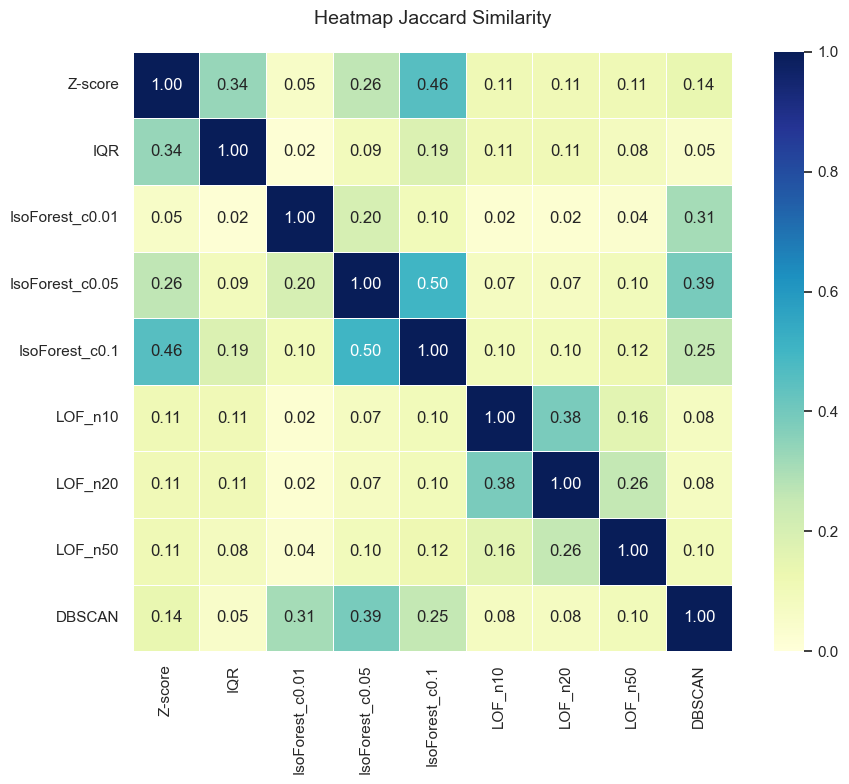

In [7]:
plot_jaccard_heatmap(outlier_masks)

### Nhận xét từ Heatmap Jaccard Similarity

* **Tổng quan:** Các giá trị Jaccard thấp (<0.3) cho thấy sự bất đồng lớn giữa các phương pháp → khái niệm ngoại lai phụ thuộc mạnh vào từng thuật toán.

* **Isolation Forest:** Có tính ổn định cao (ví dụ Jaccard = 0.5 giữa c0.05 và c0.1) → các tập ngoại lai có quan hệ dạng tập con.

* **DBSCAN & Isolation Forest:** Có mức đồng thuận tương đối (≈0.3–0.4) → các điểm bị DBSCAN coi là nhiễu cũng thường là ngoại lai theo Isolation Forest.

* **LOF:** Jaccard thấp với các phương pháp khác → do dựa trên mật độ cục bộ nên khó phát hiện ngoại lai toàn cục.

* **Z-score & IQR:** Đồng thuận thấp, đặc biệt IQR gần như lệch pha với các phương pháp khác → không phù hợp với dữ liệu bị lệch.

**Kết luận:** Không có phương pháp nào vượt trội tuyệt đối. Nên kết hợp nhiều phương pháp (ensemble) để xác định ngoại lai đáng tin cậy hơn.


In [8]:
# Kiểm định KS-Test và lọc các phân phối bị biến đổi
df_ks = evaluate_ks_test(df_num, outlier_masks)
changed_distributions = df_ks[df_ks['Change_H0'] == 'Reject (Changed)']
display(changed_distributions)

,Method,Feature,Outliers_Found,p_value,Change_H0
0,Z-score,lead_time,21781,1.194347e-07,Reject (Changed)
1,Z-score,stays_in_weekend_nights,21781,7.530179e-18,Reject (Changed)
2,Z-score,stays_in_week_nights,21781,5.488099e-22,Reject (Changed)
4,Z-score,children,21781,3.246356e-58,Reject (Changed)
5,Z-score,babies,21781,3.523622e-03,Reject (Changed)
...,...,...,...,...,...
108,DBSCAN,children,3306,6.544106e-04,Reject (Changed)
112,DBSCAN,booking_changes,3306,1.495894e-12,Reject (Changed)
114,DBSCAN,adr,3306,2.236313e-02,Reject (Changed)
115,DBSCAN,required_car_parking_spaces,3306,1.528355e-02,Reject (Changed)


### Nhận xét từ kiểm định KS (sau khi loại ngoại lai bằng Z-score)

* **Phân phối bị biến dạng:** Tất cả p-value rất nhỏ (< 0.05) → bác bỏ $H_0$ → việc loại ngoại lai đã làm thay đổi mạnh phân phối dữ liệu.

* **Xóa dữ liệu quá nhiều:** 21,781 dòng (~18.24%) bị loại do cơ chế xóa theo dòng → làm ảnh hưởng cả những biến vốn bình thường.

* **Biến lệch về 0 bị phá vỡ:** Các biến như *children*, *babies*,… chủ yếu = 0. Z-score loại bỏ các giá trị hiếm → mất thông tin quan trọng, làm sai lệch phân phối.

* **Biến liên tục bị cắt đuôi:** *adr*, *lead_time* có phân phối lệch phải → Z-score cắt mất phần tail → làm sai hình dạng dữ liệu.

**Kết luận:** Z-score (và việc drop outlier) không phù hợp.
- Nên giữ dữ liệu và dùng mô hình tree-based
- Hoặc dùng Winsorization / Quantile Transform thay vì xóa dữ liệu


### c) Lý thuyết: Chuẩn hóa dữ liệu có kiểm định

Chuẩn hóa dữ liệu (Feature Scaling) là một bước tiền xử lý quan trọng, đặc biệt đối với các mô hình học máy dựa trên khoảng cách (như KNN, SVM) hoặc sử dụng thuật toán tối ưu hóa Gradient Descent (như Neural Networks, Logistic Regression). Việc đưa các đặc trưng về cùng một thang đo giúp mô hình hội tụ nhanh hơn và không bị chệch hướng bởi các đặc trưng có giá trị quá lớn.

#### 1. Các phương pháp chuẩn hóa dữ liệu

**Min-Max Scaling (Normalization):**
Phương pháp này nén dữ liệu về một khoảng cố định, thường là $[0, 1]$. Nó giữ nguyên hình dáng phân phối gốc nhưng rất nhạy cảm với các điểm ngoại lai (outliers).
* **Công thức:** $$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**Z-score Scaling (Standardization):**
Phương pháp này giả định dữ liệu tuân theo phân phối chuẩn. Dữ liệu sau khi chuẩn hóa sẽ có giá trị trung bình $\mu = 0$ và độ lệch chuẩn $\sigma = 1$. Nó ít nhạy cảm với ngoại lai hơn Min-Max nhưng vẫn có thể bị ảnh hưởng nếu ngoại lai quá lớn.
* **Công thức:**
    $$X_{std} = \frac{X - \mu}{\sigma}$$

**Robust Scaling:**
Tương tự như Z-score nhưng sử dụng các đại lượng thống kê có tính chống chịu cao với ngoại lai là trung vị (Median - $Q_2$) và khoảng tứ phân vị (IQR). Do đó, sự hiện diện của các điểm cực đoan không làm sai lệch quá trình chuẩn hóa.
* **Công thức:**
    $$X_{robust} = \frac{X - Q_2}{Q_3 - Q_1}$$

**Quantile Transform:**
Đây là một phép biến đổi phi tuyến tính (non-linear transformation). Thuật toán sử dụng hàm phân phối tích lũy (CDF) để ánh xạ dữ liệu gốc sang một phân phối mục tiêu, làm mượt các phân phối bất thường và vô hiệu hóa hoàn toàn tác động của ngoại lai.
* **Uniform output:** Ánh xạ dữ liệu sao cho các giá trị trải đều đặn trong khoảng $[0, 1]$ (phân phối đều).
* **Normal output:** Ánh xạ dữ liệu về phân phối chuẩn $\mathcal{N}(0, 1)$ bằng cách áp dụng hàm lượng tử nghịch đảo. Kỹ thuật này rất hữu ích khi các mô hình yêu cầu khắt khe về giả định phân phối chuẩn.

#### 2. Kiểm định tính đồng nhất phương sai (Levene’s Test)

Trong phân tích thống kê và học máy (đặc biệt với các mô hình tuyến tính, ANOVA), **homoscedasticity** (tính đồng nhất phương sai) là một giả định quan trọng. Nó ngụ ý rằng phương sai của các đặc trưng độc lập (hoặc sai số) không thay đổi trên các mức độ khác nhau của biến mục tiêu (target variable).

Kiểm định Levene được sử dụng để kiểm tra xem các nhóm dữ liệu (ví dụ: dữ liệu thuộc tính $X$ được chia theo các nhóm của nhãn $Y$) có phương sai bằng nhau hay không. Levene's test có tính robust tốt hơn Bartlett's test khi dữ liệu không tuân theo phân phối chuẩn hoàn hảo.

* **Giả thuyết không ($H_0$):** Phương sai của tất cả các nhóm là bằng nhau ($\sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2$).
* **Giả thuyết thay thế ($H_a$):** Có ít nhất một nhóm có phương sai khác biệt.
* **Tiêu chí đánh giá:** Nếu $p\text{-value} < 0.05$, ta bác bỏ $H_0$, nghĩa là dữ liệu bị vi phạm giả định đồng nhất phương sai (heteroscedasticity). Chúng ta sẽ quan sát xem các phép chuẩn hóa (đặc biệt là Quantile Transform) có giúp cải thiện $p\text{-value} $ này hay không.


In [9]:
def apply_scalers(df, features):

    scalers = {
        'Original': None,
        'Min-Max': MinMaxScaler(),
        'Z-score': StandardScaler(),
        'Robust': RobustScaler(),
        'Quantile (Uniform)': QuantileTransformer(output_distribution='uniform', random_state=42),
        'Quantile (Normal)': QuantileTransformer(output_distribution='normal', random_state=42)
    }

    scaled_data = {'is_canceled': df['is_canceled'].values}

    for name, scaler in scalers.items():
        if scaler is None:
            for feat in features:
                scaled_data[f'{feat}_{name}'] = df[feat].values
        else:
            scaled_array = scaler.fit_transform(df[features])
            for i, feat in enumerate(features):
                scaled_data[f'{feat}_{name}'] = scaled_array[:, i]

    return pd.DataFrame(scaled_data), scalers.keys()

def perform_levene_test(df_scaled, features, scaler_names):
    results = []

    # Tách mask cho 2 nhóm mục tiêu
    mask_canceled = df_scaled['is_canceled'] == 1
    mask_not_canceled = df_scaled['is_canceled'] == 0

    for feat in features:
        for name in scaler_names:
            col_name = f'{feat}_{name}'

            group1 = df_scaled.loc[mask_canceled, col_name].dropna()
            group2 = df_scaled.loc[mask_not_canceled, col_name].dropna()

            # Kiểm định Levene: H0 là phương sai 2 nhóm bằng nhau
            stat, p_value = stats.levene(group1, group2)

            results.append({
                'Feature': feat,
                'Scaler': name,
                'Levene_Stat': stat,
                'p_value': p_value,
                'Homoscedasticity': 'Yes (Accept H0)' if p_value >= 0.05 else 'No (Reject H0)'
            })

    return pd.DataFrame(results)

def plot_violin_distributions(df_scaled, features, scaler_names):
    for feat in features:
        cols_to_melt = [f'{feat}_{name}' for name in scaler_names]
        df_melt = pd.melt(df_scaled, value_vars=cols_to_melt, var_name='Scaler_Type', value_name='Value')

        df_melt['Scaler_Type'] = df_melt['Scaler_Type'].apply(lambda x: x.replace(f'{feat}_', ''))

        plt.figure(figsize=(14, 6))

        sns.violinplot(x='Scaler_Type', y='Value', data=df_melt, palette='muted', inner='quartile')

        plt.title(f'Phân phối của {feat} qua các phương pháp chuẩn hóa', fontsize=14, pad=15)
        plt.xlabel('Phương pháp chuẩn hóa', fontsize=12)
        plt.ylabel('Giá trị', fontsize=12)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

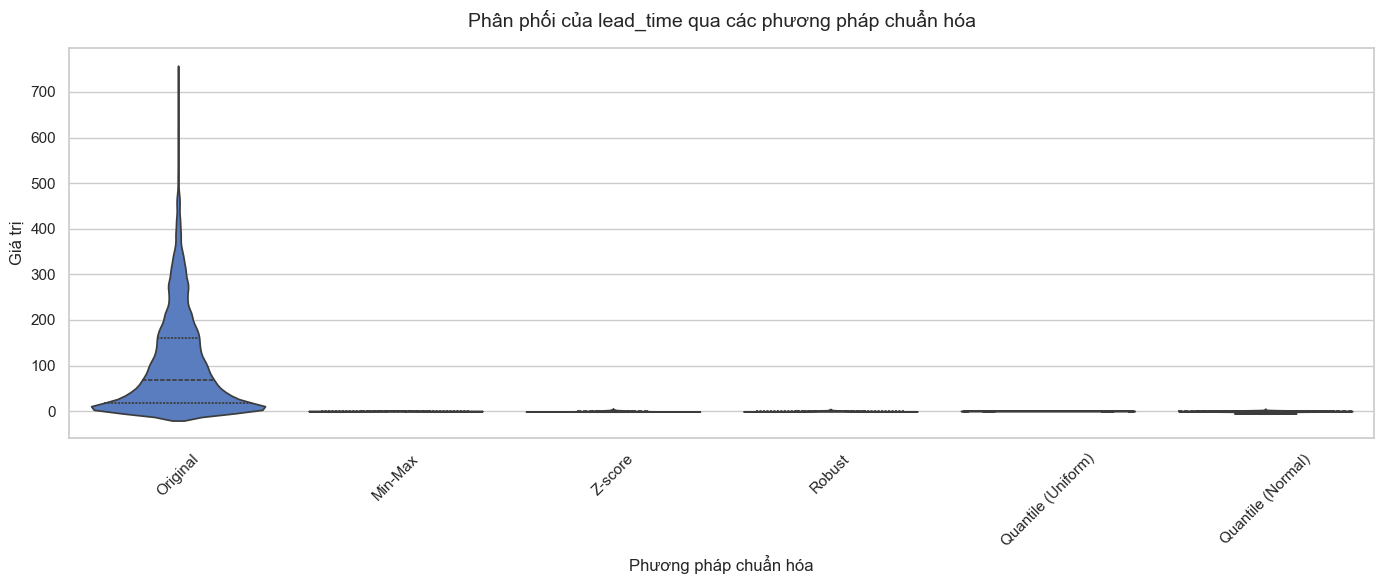

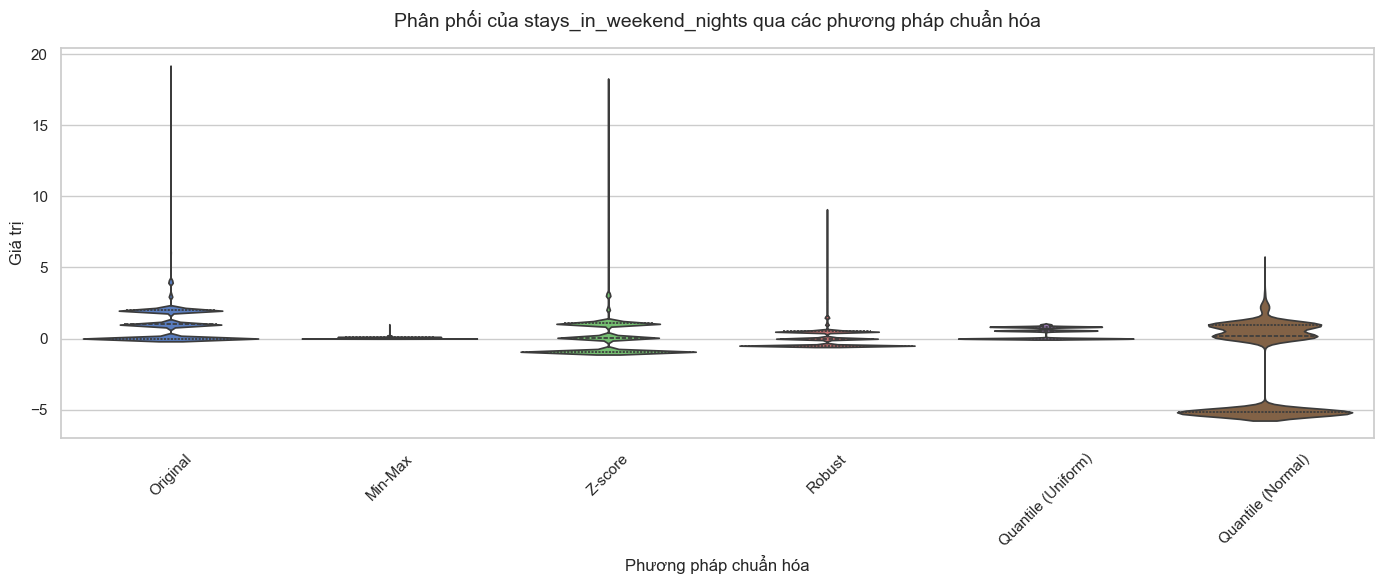

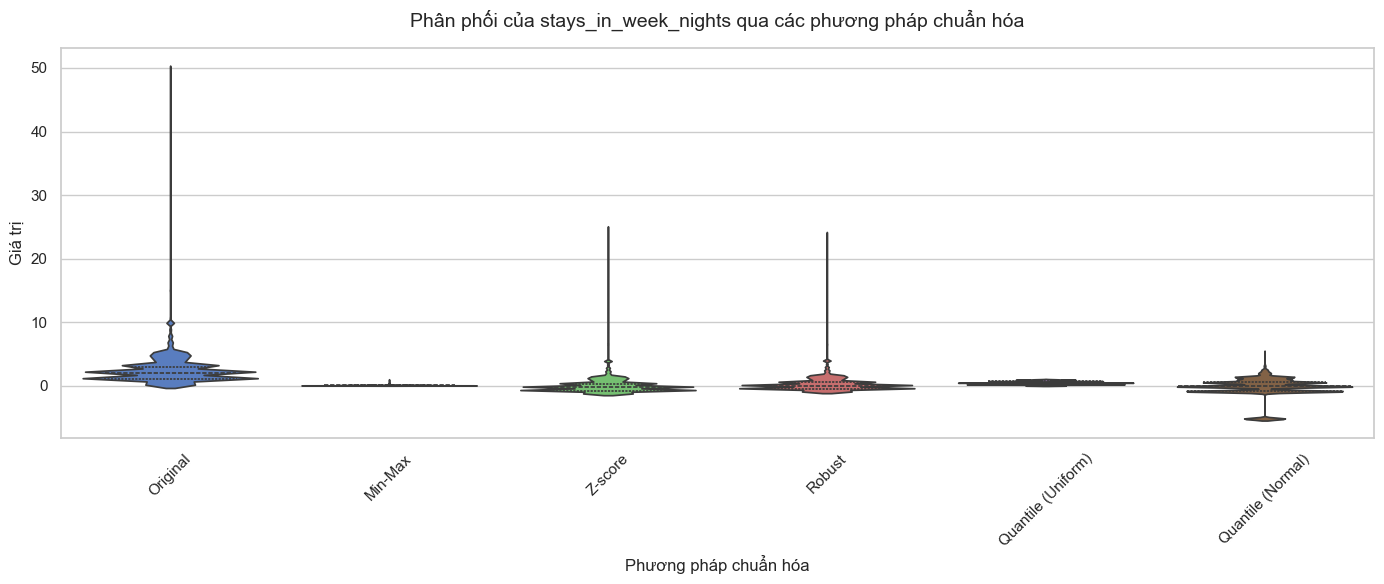

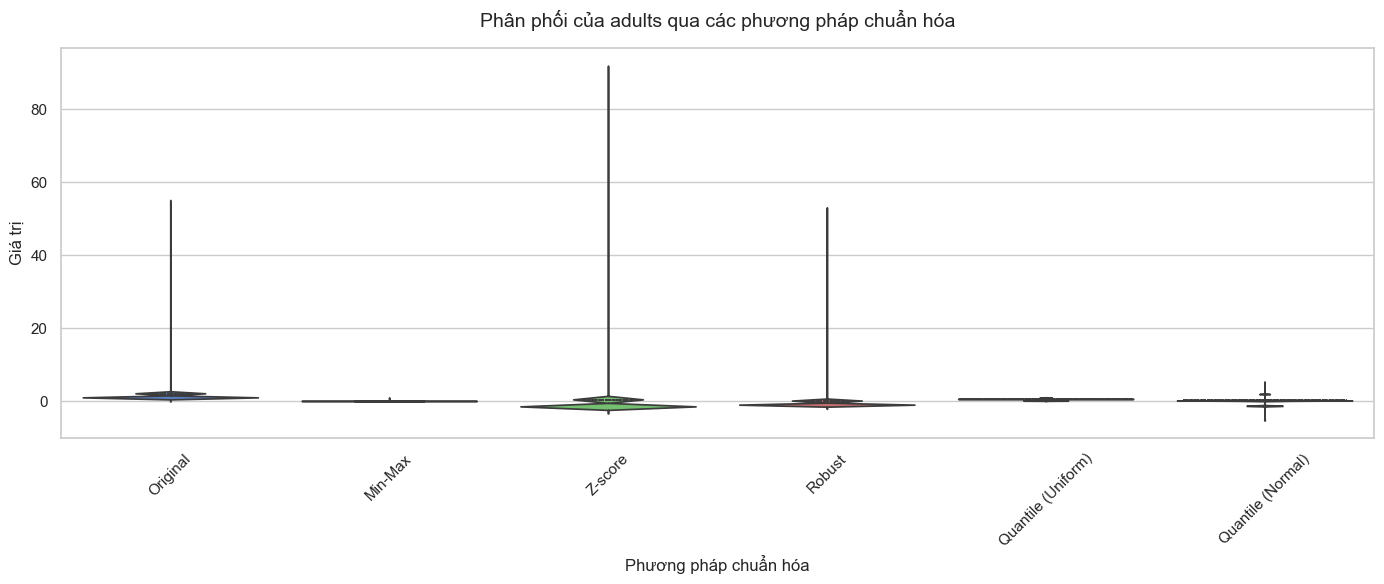

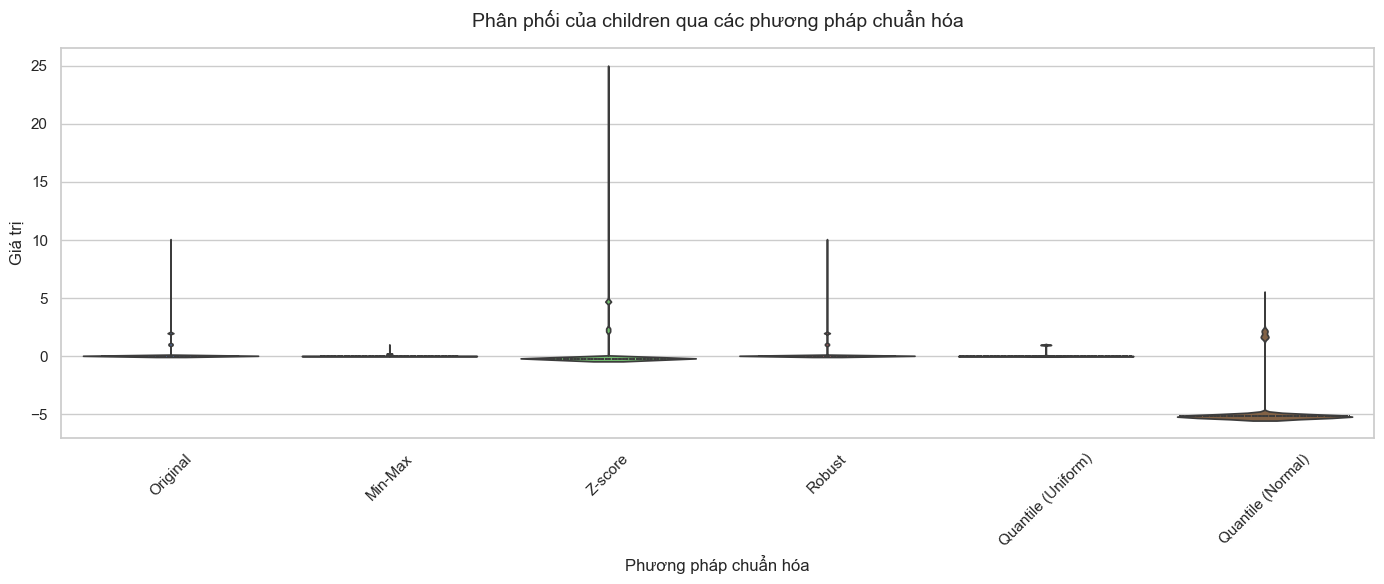

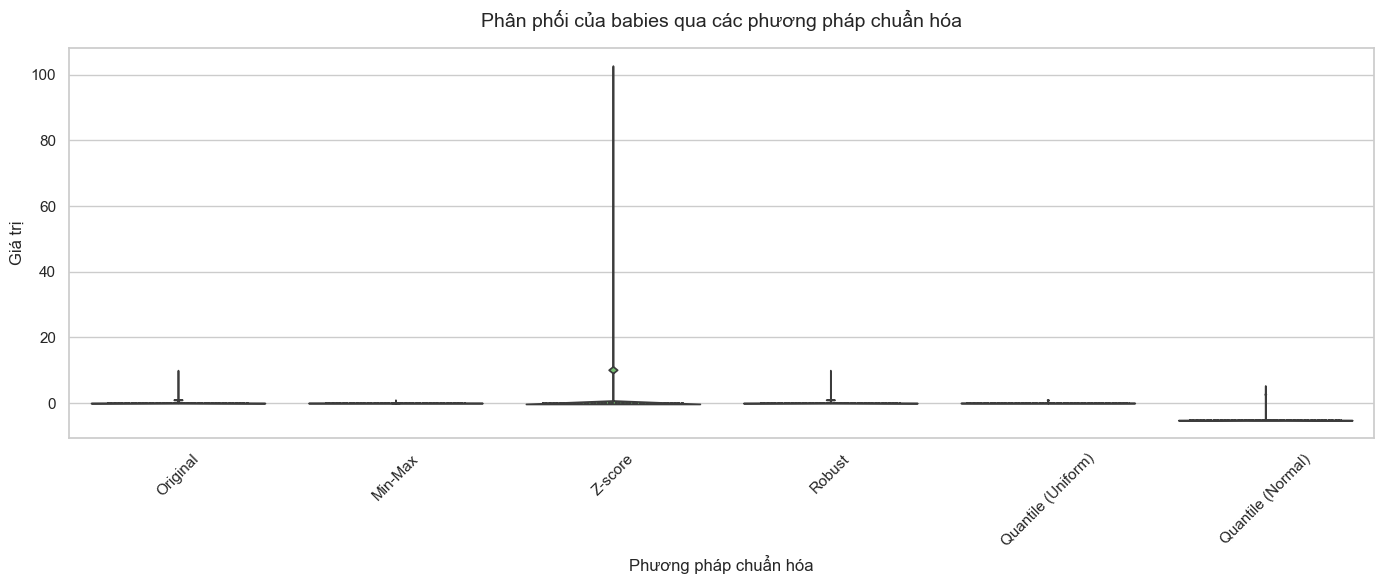

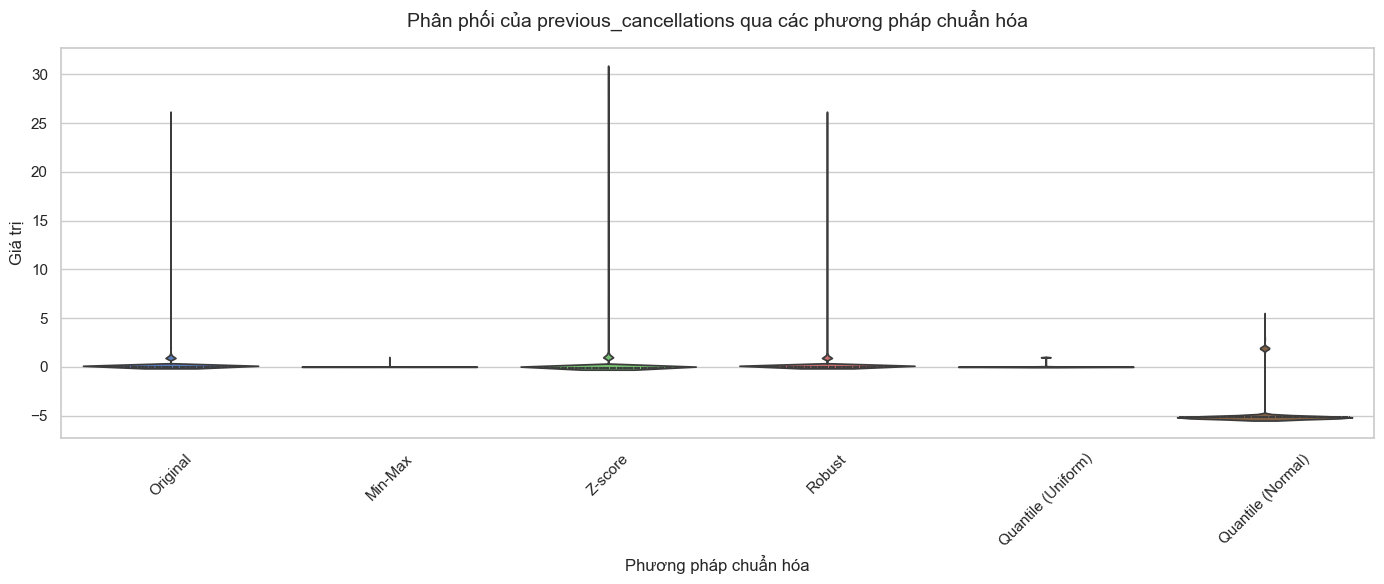

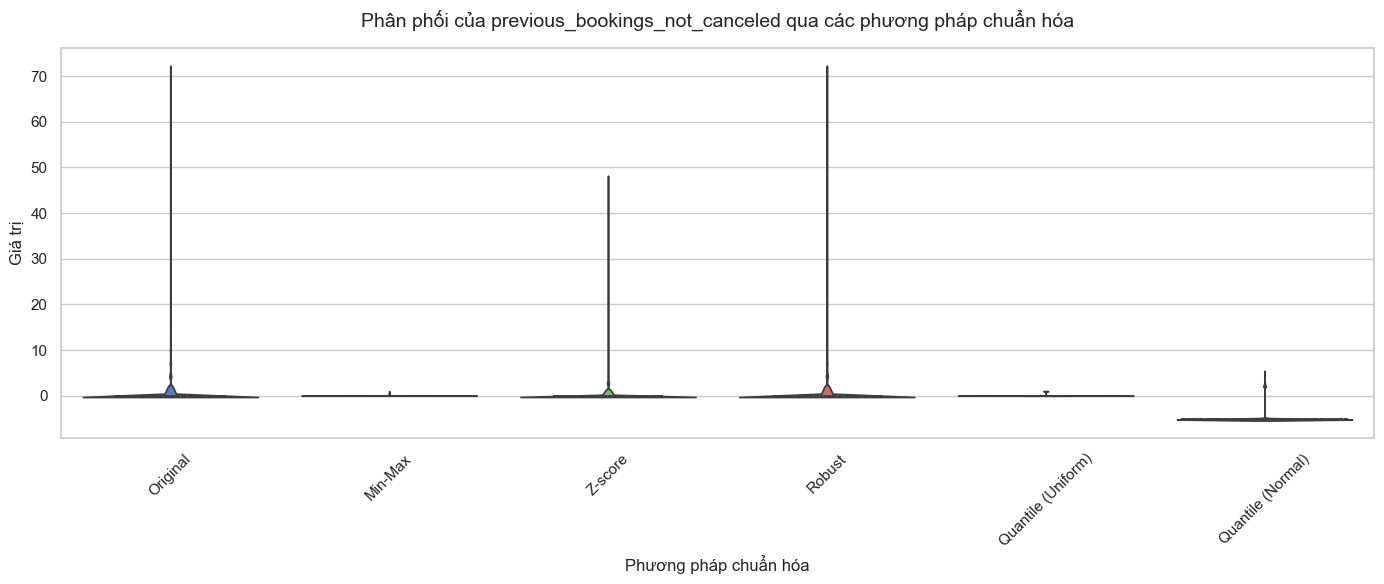

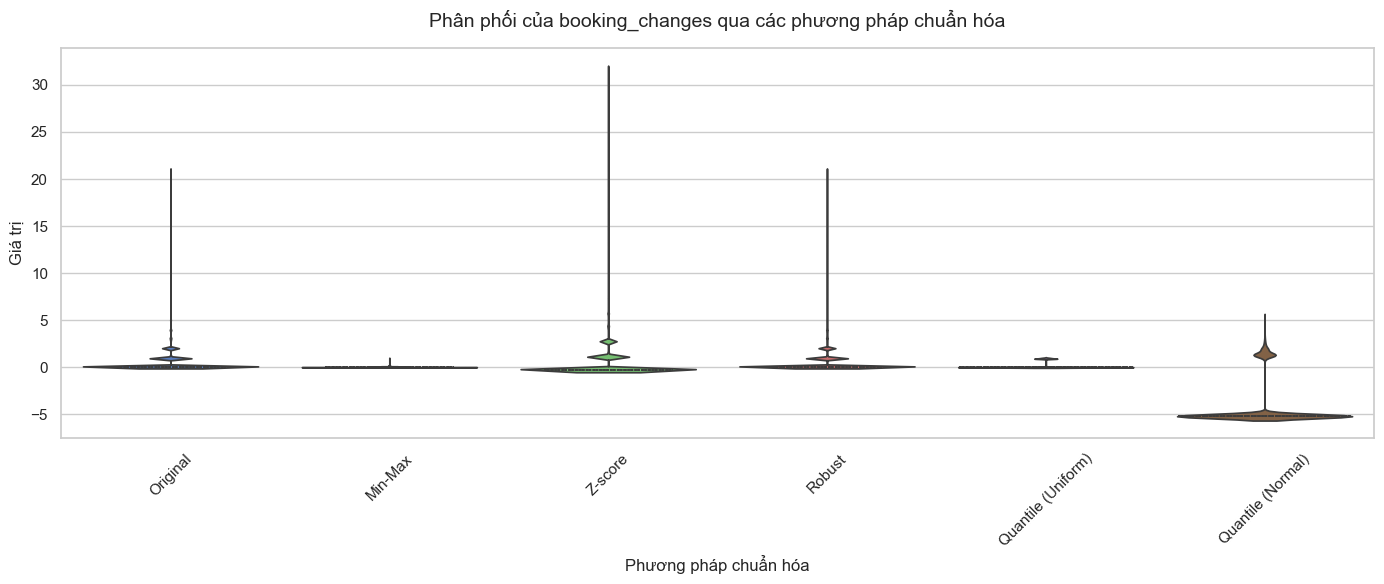

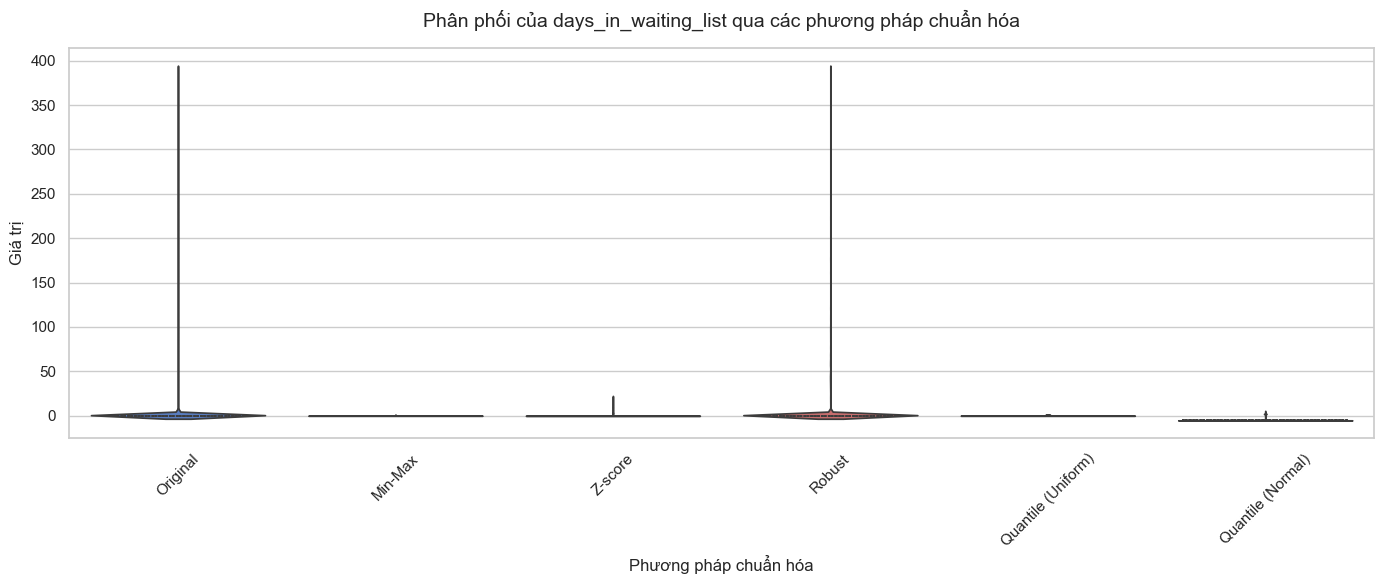

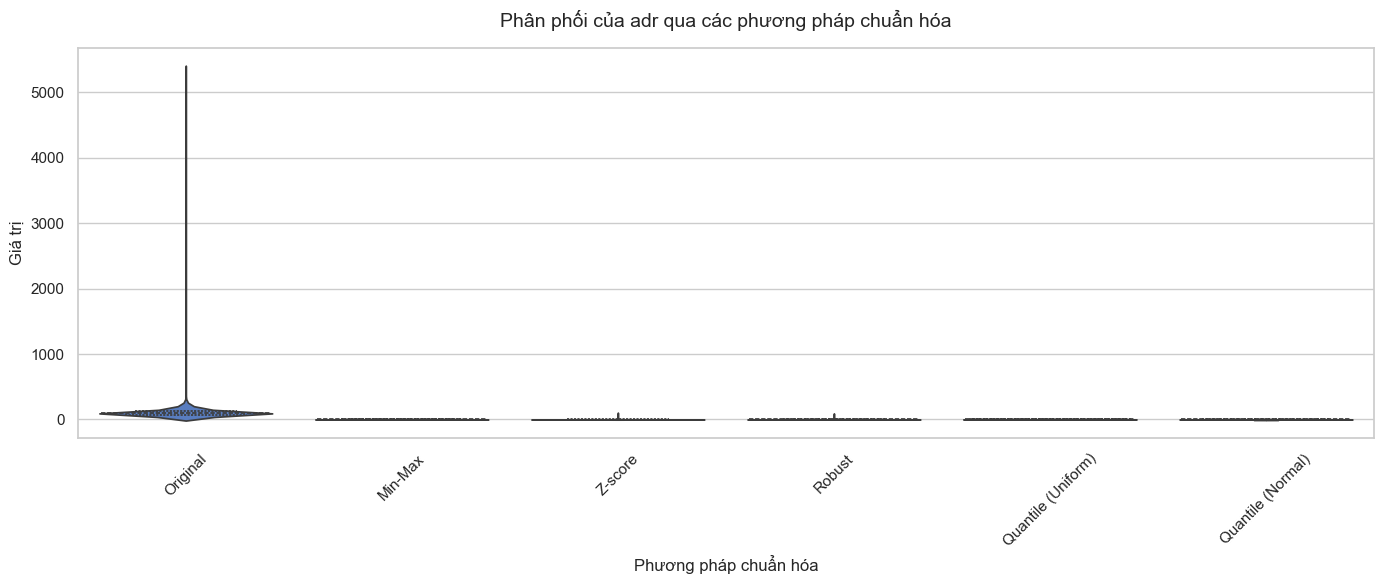

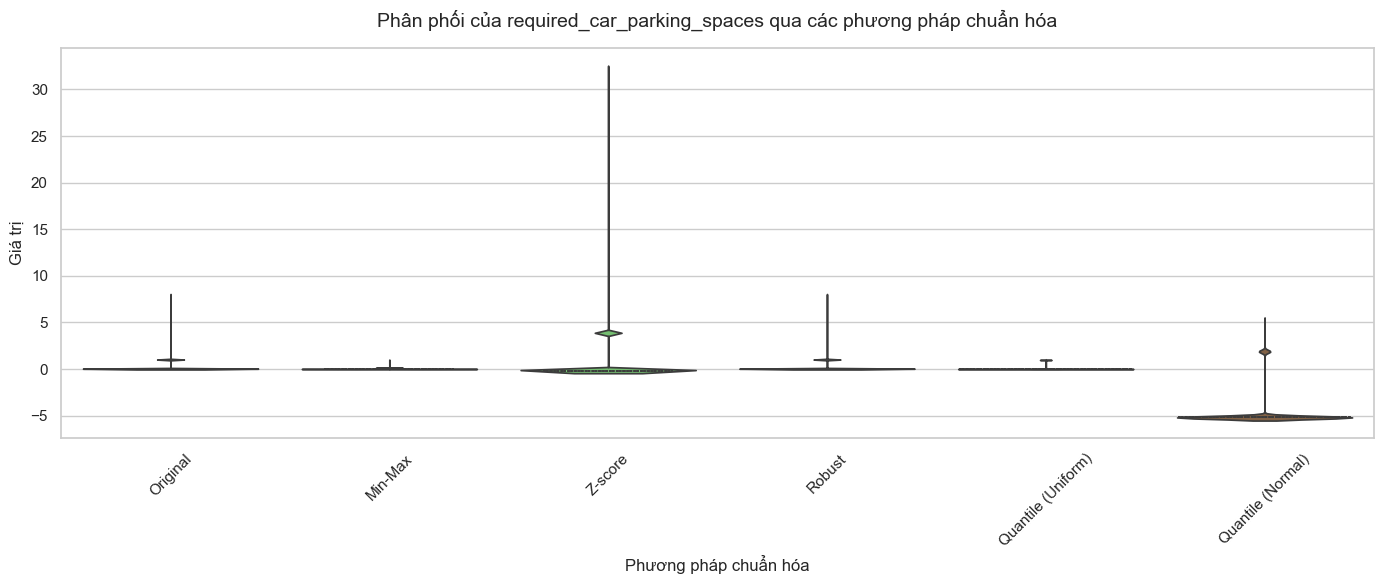

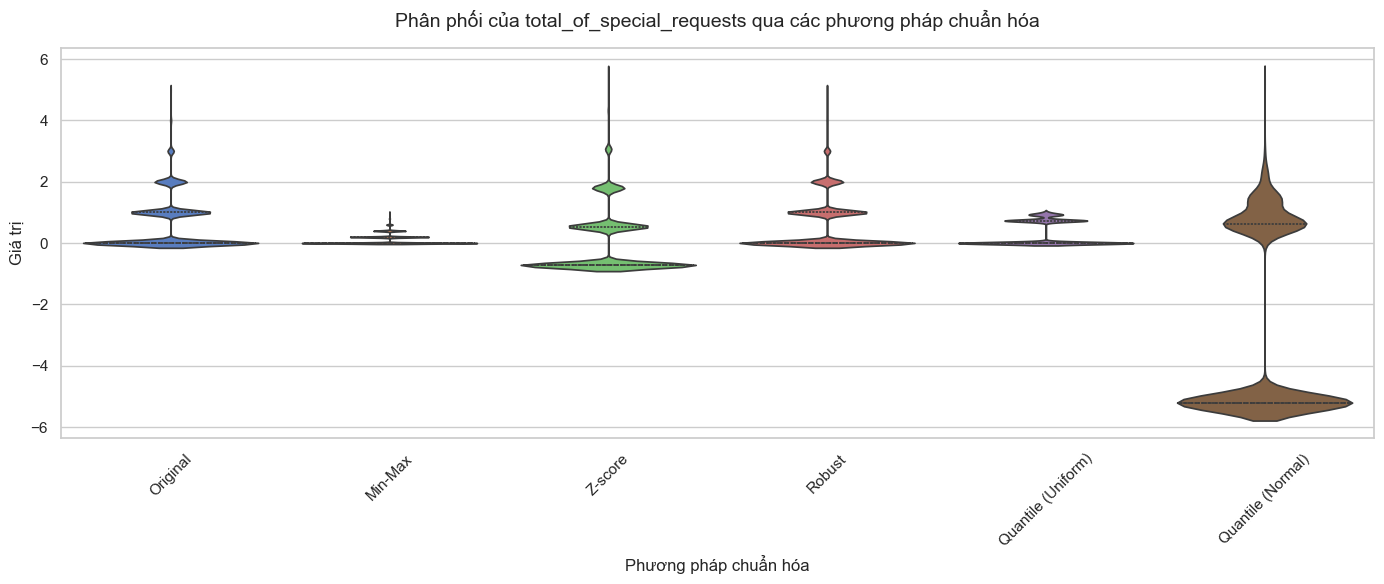

In [10]:
features_to_scale = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests'
]

cols_to_keep = features_to_scale + ['is_canceled']
df_subset = df[cols_to_keep].copy().dropna()

df_scaled, scaler_names = apply_scalers(df_subset, features_to_scale)

plot_violin_distributions(df_scaled, features_to_scale, scaler_names)

### Nhận xét từ biểu đồ Violin (trước & sau chuẩn hóa)

* **Chuẩn hóa tuyến tính (Min-Max, Z-score, Robust):**
  Không thay đổi hình dạng phân phối, chỉ co giãn trục giá trị. Dữ liệu bị lệch mạnh và có ngoại lai → phần lớn điểm bị “ép dẹt”, không cải thiện khả năng học của mô hình.

* **Quantile Transform (biến liên tục):**
  Hiệu quả với các biến như *lead_time*, *adr* → đưa phân phối về gần chuẩn, giảm ảnh hưởng ngoại lai → phù hợp cho mô hình tuyến tính.

* **Hạn chế của Quantile Transform:**

  * Với biến rời rạc: làm mất cấu trúc phân lớp tự nhiên
  * Với biến zero-inflated: không cải thiện, gây méo phân phối

**Kết luận:**
Không có phương pháp chuẩn hóa chung cho tất cả.
- Quantile → biến liên tục lệch mạnh
- Min-Max / Z-score → biến rời rạc


### d) Lý thuyết: Mã hóa biến phân loại nâng cao và Kiểm soát Đa cộng tuyến

Hầu hết các thuật toán học máy (ngoại trừ các thuật toán dựa trên cây như Random Forest hay CatBoost) đều yêu cầu dữ liệu đầu vào là dạng số. Việc chuyển đổi từ biến phân loại (Categorical) sang biến số (Numerical) cần được thực hiện cẩn trọng để không làm mất thông tin hoặc gây nhiễu cho mô hình.

#### 1. Các phương pháp mã hóa cơ sở (Baseline)

* **One-Hot Encoding (OHE):**
    Biến đổi mỗi giá trị duy nhất của một thuộc tính thành một cột nhị phân (0 hoặc 1).
    * **Ưu điểm:** Phù hợp với biến định danh (Nominal) không có thứ tự.
    * **Nhược điểm:** Dễ gây bùng nổ số chiều nếu biến có nhiều giá trị (High-cardinality).
    * **Lưu ý:** Cần chú ý đến **Bẫy biến giả (Dummy Variable Trap)** khi tổng các cột bằng 1, gây đa cộng tuyến hoàn hảo. Thường xử lý bằng cách loại bỏ một cột đầu tiên ($N-1$ cột).
    

* **Ordinal Encoding:**
    Gán cho mỗi hạng mục một giá trị số nguyên theo một thứ tự nhất định.
    * **Ưu điểm:** Không làm tăng số chiều của dữ liệu.
    * **Nhược điểm:** Có thể gây hiểu lầm cho mô hình rằng các nhãn có quan hệ thứ tự toán học (ví dụ: $3 > 1$) ngay cả khi bản chất dữ liệu không có tính chất này.

#### 2. Các phương pháp mã hóa nâng cao

* **Target Encoding (Mean Encoding) với Cross-Validation:**
    Thay thế nhãn phân loại bằng giá trị trung bình của biến mục tiêu ($Y$) tương ứng với nhãn đó.
    * **Công thức:** $TE(c) = E[Y | X = c]$
    * **Vấn đề:** Dễ gây ra **Target Leakage** (rò rỉ thông tin mục tiêu), dẫn đến Overfitting.
    * **Giải pháp:** Sử dụng K-Fold Cross-Validation để tính toán giá trị mã hóa cho mỗi điểm dữ liệu dựa trên thông tin của các phần (folds) dữ liệu khác.

* **Binary Encoding:**
    Kết hợp giữa Ordinal Encoding và biểu diễn nhị phân.
    * **Quy trình:** Chuyển nhãn thành số nguyên $\rightarrow$ Chuyển số nguyên thành chuỗi bit nhị phân $\rightarrow$ Tách mỗi bit thành một cột.
    * **Ưu điểm:** Rất hiệu quả cho các biến có nhiều giá trị (High-cardinality $> 20$). Số lượng cột sinh ra chỉ là $\lceil \log_2(N) \rceil$ thay vì $N$ cột như One-Hot.

* **Frequency Encoding:**
    Thay thế nhãn bằng tần suất xuất hiện (tỉ lệ %) của nó trong tập dữ liệu.
    * **Công thức:** $Freq(c) = \frac{count(c)}{count(total)}$
    * **Ý nghĩa:** Giúp mô hình nắm bắt được độ phổ biến của các nhóm dữ liệu.

#### 3. Kiểm soát Đa cộng tuyến bằng VIF (Variance Inflation Factor)

Sau khi mã hóa, đặc biệt là One-Hot, các biến mới có thể tương quan mạnh với nhau, gây ra hiện tượng đa cộng tuyến. Điều này làm sai lệch ý nghĩa các hệ số trong các mô hình hồi quy.

**Công thức tính VIF cho biến $X_i$:**
$$VIF_i = \frac{1}{1 - R_i^2}$$
Trong đó $R_i^2$ là hệ số xác định khi hồi quy biến $X_i$ theo tất cả các biến độc lập còn lại.

**Tiêu chuẩn đánh giá:**
| Giá trị VIF | Ý nghĩa | Hành động |
| :--- | :--- | :--- |
| **VIF = 1** | Không có tương quan. | Rất tốt. |
| **1 < VIF < 5** | Tương quan vừa phải. | Chấp nhận được. |
| **VIF > 5 (hoặc 10)** | Đa cộng tuyến nghiêm trọng. | Cần xem xét loại bỏ đặc trưng hoặc thay đổi phương pháp mã hóa. |


### Train/Test Split và Xử lý Target Leakage

Thực hiện chia dữ liệu thành tập **Train/Test** và loại bỏ các biến gây **rò rỉ dữ liệu (Target Leakage)** như `reservation_status`, `reservation_status_date` nhằm đảm bảo mô hình học đúng bản chất và có khả năng tổng quát hóa tốt trên dữ liệu thực tế.

### Lý do cần loại bỏ

* **Temporal Leakage (rò rỉ thời gian)**
  `reservation_status` và `reservation_status_date` là thông tin chỉ có **sau khi sự kiện xảy ra** → không tồn tại tại thời điểm dự báo ⇒ khiến mô hình không áp dụng được trong thực tế.

* **Mô hình học sai bản chất**
  Thuật toán sẽ phụ thuộc hoàn toàn vào các biến này ⇒ bỏ qua các đặc trưng quan trọng khác → tạo ra kết quả **ảo (độ chính xác cao nhưng không có giá trị thực tiễn)**.



In [11]:
# 1. Loại bỏ dữ liệu gây rò rỉ thông tin
leakage_cols = ['reservation_status', 'reservation_status_date']
df_clean = df.drop(columns=[c for c in leakage_cols if c in df.columns])

# 2. Chia tập TRAIN/TEST
X = df_clean.drop(columns=['is_canceled'])
y = df_clean['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (95512, 29), X_test: (23878, 29)


In [12]:
# 1. HÀM TÍNH VIF
def calculate_vif(df_encoded):
    X_vif = add_constant(df_encoded.select_dtypes(include=[np.number]).dropna())
    vif_data = pd.DataFrame({"Feature": X_vif.columns})

    vif_values = []
    for i in range(len(X_vif.columns)):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
        except:
            vif = np.inf
        vif_values.append(vif)

    vif_data["VIF"] = vif_values
    return vif_data[vif_data["Feature"] != "const"]


# 2. CUSTOM TARGET ENCODER
def custom_target_encoder_cv(X_tr, y_tr, X_te, col, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    train_encoded = pd.Series(index=X_tr.index, dtype=float)
    global_mean = y_tr.mean()

    # Mã hóa tập Train bằng K-Fold
    for train_idx, val_idx in kf.split(X_tr):
        X_fold_train, y_fold_train = X_tr.iloc[train_idx], y_tr.iloc[train_idx]

        target_means = y_fold_train.groupby(X_fold_train[col]).mean()

        train_encoded.iloc[val_idx] = X_tr.iloc[val_idx][col].map(target_means).fillna(global_mean)

    # Mã hóa tập Test bằng toàn bộ tập Train
    full_target_means = y_tr.groupby(X_tr[col]).mean()
    test_encoded = X_te[col].map(full_target_means).fillna(global_mean)

    return train_encoded.to_frame(name=f"{col}_target"), test_encoded.to_frame(name=f"{col}_target")

# 3. CUSTOM BINARY ENCODER
def custom_binary_encoder(X_tr, X_te, col):
    # 1. Ánh xạ hạng mục sang số nguyên (dựa trên tập train)
    categories = X_tr[col].unique()
    mapping = {cat: i for i, cat in enumerate(categories)}

    X_tr_int = X_tr[col].map(mapping)
    X_te_int = X_te[col].map(mapping).fillna(0).astype(int)

    # 2. Tính số lượng bit cần thiết
    max_val = len(categories) - 1
    num_bits = max(1, int(np.ceil(np.log2(max_val + 1))))

    col_names = [f"{col}_bin_{i}" for i in range(num_bits)]

    # 3. Chuyển số nguyên sang chuỗi bit và tách cột
    def to_binary_df(series_int):
        bin_strs = series_int.apply(lambda x: format(x, f'0{num_bits}b'))
        bin_df = bin_strs.apply(lambda x: pd.Series(list(x))).astype(int)
        bin_df.columns = col_names
        return bin_df

    return to_binary_df(X_tr_int), to_binary_df(X_te_int)

# 4. ÁP DỤNG CÁC PHƯƠNG PHÁP
def apply_all_custom_encodings(X_train, y_train, X_test, col):
    results_train, results_test = {}, {}
    X_tr, X_te = X_train[[col]], X_test[[col]]

    # 1. One-Hot Encoding
    ohe_tr = pd.get_dummies(X_tr[col], prefix=col, drop_first=True, dtype=int)
    ohe_te = pd.get_dummies(X_te[col], prefix=col, drop_first=True, dtype=int).reindex(columns=ohe_tr.columns, fill_value=0)
    results_train['One-Hot'] = ohe_tr
    results_test['One-Hot'] = ohe_te

    # 2. Ordinal Encoding
    orde = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    results_train['Ordinal'] = pd.DataFrame(orde.fit_transform(X_tr), columns=[f"{col}_ord"], index=X_tr.index)
    results_test['Ordinal'] = pd.DataFrame(orde.transform(X_te), columns=[f"{col}_ord"], index=X_te.index)

    # 3. Frequency Encoding
    freq_map = X_tr[col].value_counts(normalize=True)
    results_train['Frequency'] = X_tr[col].map(freq_map).to_frame(name=f"{col}_freq")
    results_test['Frequency'] = X_te[col].map(freq_map).fillna(0).to_frame(name=f"{col}_freq")

    # 4. Binary Encoding (Custom)
    results_train['Binary'], results_test['Binary'] = custom_binary_encoder(X_tr, X_te, col)

    # 5. Target Encoding CV (Custom)
    results_train['Target (CV)'], results_test['Target (CV)'] = custom_target_encoder_cv(X_tr, y_train, X_te, col)

    return results_train, results_test

In [13]:
# Lựa chọn biến High-Cardinality (> 20 giá trị)
cat_feature = 'country'

numeric_cont_cols = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests', 'arrival_date_week_number', 'arrival_date_day_of_month'
]

mask_train = X_train[cat_feature].notnull()
mask_test = X_test[cat_feature].notnull()

print(f"Thuộc tính: {cat_feature}\n")
print(f"Số lượng nhãn duy nhất (Cardinality): {X_train.loc[mask_train, cat_feature].nunique()} \n")

train_encoded, test_encoded = apply_all_custom_encodings(
    X_train.loc[mask_train],
    y_train.loc[mask_train],
    X_test.loc[mask_test],
    cat_feature
)

# Lấy danh sách cột số
numeric_anchors = X_train.loc[mask_train, numeric_cont_cols]

imputer_vif = SimpleImputer(strategy='median')
numeric_anchors_clean = pd.DataFrame(
    imputer_vif.fit_transform(numeric_anchors),
    columns=numeric_anchors.columns,
    index=numeric_anchors.index
)

vif_report = []

for name, df_train_res in train_encoded.items():
    print(f"[*] Phương pháp: {name}")
    print(f"    Số lượng cột sinh ra: {df_train_res.shape[1]}")

    display_df = pd.concat([X_train.loc[mask_train, [cat_feature]].head(3), df_train_res.head(3)], axis=1)

    if name == 'One-Hot':
        display_df = display_df.iloc[:, :6]

    display(display_df)
    print("-" * 50)

    # Ghép cột mã hóa mới với toàn bộ 15 biến số
    combined_for_vif = pd.concat([numeric_anchors_clean, df_train_res], axis=1)

    # Tính VIF tổng
    vif_df = calculate_vif(combined_for_vif)

    new_cols = df_train_res.columns
    vif_of_new_cols = vif_df[vif_df['Feature'].isin(new_cols)]['VIF']

    vif_report.append({
        'Phương pháp': name,
        'Số cột': df_train_res.shape[1],
        'VIF Max': round(vif_of_new_cols.max(), 3),
        'VIF Mean': round(vif_of_new_cols.mean(), 3)
    })

df_vif_report = pd.DataFrame(vif_report)
print("\n=== BẢNG TỔNG KẾT SO SÁNH ĐA CỘNG TUYẾN (VIF) TẬP TRAIN ===")
display(df_vif_report.style.highlight_min(subset=['VIF Mean'], color='lightgreen'))

Thuộc tính: country

Số lượng nhãn duy nhất (Cardinality): 172 

[*] Phương pháp: One-Hot
    Số lượng cột sinh ra: 171


,country,country_AGO,country_AIA,country_ALB,country_AND,country_ARE
105447,IRL,0,0,0,0,0
85242,FRA,0,0,0,0,0
65604,PRT,0,0,0,0,0


--------------------------------------------------
[*] Phương pháp: Ordinal
    Số lượng cột sinh ra: 1


,country,country_ord
105447,IRL,73.0
85242,FRA,54.0
65604,PRT,130.0


--------------------------------------------------
[*] Phương pháp: Frequency
    Số lượng cột sinh ra: 1


...

,country,country_bin_0,country_bin_1,country_bin_2,country_bin_3,country_bin_4,country_bin_5,country_bin_6,country_bin_7
105447,IRL,0,0,0,0,0,0,0,0
85242,FRA,0,0,0,0,0,0,0,1
65604,PRT,0,0,0,0,0,0,1,0


--------------------------------------------------
[*] Phương pháp: Target (CV)
    Số lượng cột sinh ra: 1


,country,country_target
105447,IRL,0.249767
85242,FRA,0.184475
65604,PRT,0.566955


--------------------------------------------------

=== BẢNG TỔNG KẾT SO SÁNH ĐA CỘNG TUYẾN (VIF) TẬP TRAIN ===


,Phương pháp,Số cột,VIF Max,VIF Mean
0,One-Hot,171,11500.582000,223.938000
1,Ordinal,1,1.073000,1.073000
2,Frequency,1,1.129000,1.129000
3,Binary,8,1.313000,1.159000
4,Target (CV),1,1.102000,1.102000


### 1. Nhận xét kết quả mã hóa cho biến `country` (High-Cardinality)

Dựa trên bảng chỉ số kiểm định đa cộng tuyến chéo (kết hợp với không gian biến số gốc), chúng ta đánh giá các phương pháp như sau:

* **One-Hot Encoding:**
  * **Nhược điểm:** Gây bùng nổ không gian dữ liệu (Sparse Matrix) khi sinh ra tới **171 cột**.
  * **Đa cộng tuyến:** Chỉ số **VIF Max cực cao (~11,500)** minh chứng cho hiện tượng **Dummy Variable Trap** (Bẫy biến giả) và sự phụ thuộc tuyến tính nghiêm trọng. Việc áp dụng phương pháp này sẽ phá vỡ tính ổn định của các mô hình, do đó đây là phương pháp **tệ nhất** cho nhóm biến High-Cardinality.
* **Binary Encoding:**
  * **Ưu điểm:** Là phương pháp nén dữ liệu cân bằng nhất. Thu gọn 171 nhãn quốc gia xuống chỉ còn **8 cột** nhị phân.
  * **Đa cộng tuyến:** Chỉ số **VIF Max rất thấp (~1.31)** cho thấy các cột bit được tạo ra có tính độc lập cao. Phương pháp này triệt tiêu hoàn toàn rủi ro đa cộng tuyến trong khi vẫn bảo toàn đủ lượng thông tin phân biệt (Information Gain).
* **Target, Frequency & Ordinal Encoding:**
  * **Đặc điểm:** Cùng nén dữ liệu tối đa về **1 cột duy nhất**, với chỉ số VIF lý tưởng dao động quanh mức **~1.07 - 1.12**.
  * **Ý nghĩa:** Vì đã được kiểm định chéo với 15 biến số sẵn có, mức VIF này chứng minh các phương pháp nén 1 chiều hoàn toàn không dẫm chân lên các đặc trưng số khác.
  * **Lưu ý:** Dù Ordinal có VIF thấp nhất nhưng sẽ tạo ra thứ tự giả (không hợp lý). Trong khi đó, **Target Encoding (kết hợp Cross-Validation)** mang lại sức mạnh dự báo cao nhất vì nó nhúng trực tiếp xác suất hủy phòng (Cancellation Rate) vào biến mà không gây rò rỉ dữ liệu.



---

### 2. Chiến lược áp dụng cho các thuộc tính còn lại ở bước Tiền Xử Lý

| Nhóm thuộc tính | Danh sách biến | Phương pháp | Lý do |
| :--- | :--- | :--- | :--- |
| **Đa nhãn cao (High-cardinality)** | `country`, `agent`, `company` | **Binary Encoding** | Giảm số chiều tối đa (chống bùng nổ bộ nhớ) và kiểm soát VIF nội bộ/VIF chéo luôn dưới ngưỡng an toàn. |
| **Đa nhãn thấp (Low-cardinality)** | `hotel`, `meal`, `market_segment`, `distribution_channel`, `deposit_type`, `customer_type` | **One-Hot Encoding**  | Số lượng nhãn ít nên không lo bùng nổ số chiều. Áp dụng `drop_first` giúp triệt tiêu bẫy biến giả, giữ được sự minh bạch cho thuật toán dạng cây phân nhánh. |
| **Có tính thứ tự (Ordinal)** | `arrival_date_month` | **Manual Mapping** | Gán chủ động số 1–12 cho các tháng để mô hình học được chính xác quy luật thời gian/chu kỳ mùa vụ của ngành khách sạn. |


## **Tiền xử lý dữ liệu trước khi lựa chọn đặc trưng và xử lý mất cân bằng**

### **1. Sự cần thiết của bước tiền xử lý**

Trước khi thực hiện lựa chọn đặc trưng (Ý e) và xử lý mất cân bằng lớp (Ý f), việc tiền xử lý dữ liệu là **bắt buộc** nhằm đảm bảo các thuật toán hoạt động chính xác và đáng tin cậy. Cụ thể, bước này giải quyết ba vấn đề cốt lõi:

* **Đáp ứng yêu cầu đầu vào của thuật toán:**
  Các phương pháp như Random Forest hay SMOTE/ADASYN yêu cầu dữ liệu đầu vào phải hoàn toàn ở dạng số và không chứa giá trị thiếu (NaN).

* **Đảm bảo tính nhất quán về khoảng cách:**
  SMOTE dựa trên k-NN để sinh mẫu mới, do đó các biến cần được chuẩn hóa về cùng thang đo. Nếu không, các biến có giá trị lớn (như `adr`) sẽ chi phối hoàn toàn các biến nhỏ (như `children`), dẫn đến dữ liệu tổng hợp bị sai lệch.

* **Ngăn chặn rò rỉ dữ liệu (Data Leakage):**
  Loại bỏ các biến chứa thông tin tương lai giúp mô hình học đúng bản chất dữ liệu thay vì “nhìn trước kết quả”.

---

### **2. Các kỹ thuật tiền xử lý đã áp dụng**

Nhằm giải quyết các vấn đề trên, nhóm xây dựng một pipeline tiền xử lý đồng bộ cho tập Train và Test với các bước chính:

* **Loại bỏ rò rỉ dữ liệu:**
  Xóa các biến `reservation_status` và `reservation_status_date` ngay từ đầu.

* **Bảo toàn phân phối gốc (Thích ứng với ngoại lai)**

    - Dựa trên kết quả phân tích ở Ý b, một số biến mang tính nghiệp vụ trong lĩnh vực khách sạn (như `children`, `required_car_parking_spaces`) có đặc điểm **phân phối lệch phải (right-skewed)** hoặc **zero-inflated**. Điều này khiến các phương pháp thống kê như IQR đánh dấu tỷ lệ ngoại lai rất cao (có thể vượt quá 50%), dù đây thực chất là đặc trưng tự nhiên của dữ liệu.

    - Nhận thấy mô hình Random Forest (sử dụng ở Ý e) hoạt động dựa trên cơ chế phân chia nhánh (tree-based splitting) và **ít nhạy cảm với ngoại lai**, nhóm quyết định **không áp dụng các kỹ thuật xử lý ngoại lai như Capping hoặc Trimming**.

  * Cách tiếp cận này giúp:

      * **Bảo toàn toàn bộ phương sai tự nhiên của dữ liệu**
      * **Duy trì lượng thông tin thực tế (Information Gain)** từ hành vi khách hàng
      * Tránh làm biến dạng các đặc trưng quan trọng mang ý nghĩa nghiệp vụ

* **Mã hóa biến phân loại:**

  * **Low-cardinality:** sử dụng One-Hot Encoding để tránh tạo thứ tự giả.
  * **High-cardinality (như `country`, `agent`):** sử dụng Binary Encoding nhằm giảm số chiều và tối ưu hiệu năng.

* **Chuẩn hóa dữ liệu:**
  Áp dụng **StandardScaler (Z-score)** để đưa các biến số về cùng thang đo (trung bình = 0, độ lệch chuẩn = 1).

* **Xử lý giá trị thiếu:**
  Sử dụng **k-NN Imputation ((k=10))** trên dữ liệu đã chuẩn hóa nhằm nội suy giá trị thiếu một cách chính xác nhất.

---

### **Kết quả**

Sau quá trình tiền xử lý, bộ dữ liệu đạt được các tiêu chuẩn sau:

* Toàn bộ dữ liệu đã được chuyển về **dạng số**, không còn giá trị thiếu (NaN)
* Các biến số được **chuẩn hóa đồng nhất về thang đo**
* **Phân phối gốc của dữ liệu được bảo toàn**, không bị biến dạng bởi các kỹ thuật xử lý ngoại lai



In [14]:

# Biến số liên tục (Cần Scale và Impute bằng k-NN)
numeric_cont_cols = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests', 'arrival_date_week_number', 'arrival_date_day_of_month'
]

# Biến nhị phân sẵn có (Giữ nguyên 0/1)
binary_ready_cols = ['is_repeated_guest']

# Biến Categorical (Cần Encoding)
high_card_cols = ['country', 'agent', 'company']
low_card_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel',
                 'deposit_type', 'customer_type', 'reserved_room_type', 'assigned_room_type']


# HÀM TIỀN XỬ LÝ
def prepare_data_for_feature_selection(X_train_raw, X_test_raw, y_train_raw=None):
    print("Bắt đầu tiền xử lý dữ liệu...")

    X_tr = X_train_raw.copy()
    X_te = X_test_raw.copy()

    # Loại bỏ rò rỉ dữ liệu
    leakage_cols = ['reservation_status', 'reservation_status_date']
    X_tr.drop(columns=[c for c in leakage_cols if c in X_tr.columns], inplace=True)
    X_te.drop(columns=[c for c in leakage_cols if c in X_te.columns], inplace=True)

    X_final_tr = pd.DataFrame(index=X_tr.index)
    X_final_te = pd.DataFrame(index=X_te.index)

    # Xử lý biến phân loại
    # Mã hóa High-Cardinality (Binary Encoding)
    for col in high_card_cols:
        bin_tr, bin_te = custom_binary_encoder(X_tr[[col]].fillna('NA'), X_te[[col]].fillna('NA'), col)
        X_final_tr = pd.concat([X_final_tr, bin_tr], axis=1)
        X_final_te = pd.concat([X_final_te, bin_te], axis=1)

    # Mã hóa Low-Cardinality (One-Hot Encoding)
    ohe_tr = pd.get_dummies(X_tr[low_card_cols], drop_first=True, dtype=int)
    ohe_te = pd.get_dummies(X_te[low_card_cols], drop_first=True, dtype=int).reindex(columns=ohe_tr.columns, fill_value=0)

    X_final_tr = pd.concat([X_final_tr, ohe_tr], axis=1)
    X_final_te = pd.concat([X_final_te, ohe_te], axis=1)

    # Mã hóa Ordinal cho tháng
    month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
                 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}

    month_ord_tr = X_tr['arrival_date_month'].map(month_map)
    month_ord_te = X_te['arrival_date_month'].map(month_map)

    mode_month = month_ord_tr.mode()[0]

    X_final_tr['month_ord'] = month_ord_tr.fillna(mode_month)
    X_final_te['month_ord'] = month_ord_te.fillna(mode_month)

    X_final_tr[binary_ready_cols] = X_tr[binary_ready_cols]
    X_final_te[binary_ready_cols] = X_te[binary_ready_cols]

    # Xử lý biến số
    print("Đang chuẩn hóa và điền khuyết biến số bằng k-NN (k=10)...")

    # Chuẩn hóa Z-score
    scaler = StandardScaler()
    X_tr_scaled_num = pd.DataFrame(scaler.fit_transform(X_tr[numeric_cont_cols]), columns=numeric_cont_cols, index=X_tr.index)
    X_te_scaled_num = pd.DataFrame(scaler.transform(X_te[numeric_cont_cols]), columns=numeric_cont_cols, index=X_te.index)

    # Điền khuyết bằng KNN
    knn_imputer = KNNImputer(n_neighbors=10, weights='uniform')

    X_final_tr[numeric_cont_cols] = knn_imputer.fit_transform(X_tr_scaled_num)
    X_final_te[numeric_cont_cols] = knn_imputer.transform(X_te_scaled_num)

    print("Tiền xử lý hoàn tất!")
    return X_final_tr, X_final_te

X_train_e, X_test_e = prepare_data_for_feature_selection(X_train, X_test)

print("-" * 40)
print(f"Kích thước X_train sẵn sàng cho chọn đặc trưng: {X_train_e.shape}")
print(f"Số lượng giá trị khuyết còn lại: {X_train_e.isna().sum().sum()}")
display(X_train_e.head(3))

Bắt đầu tiền xử lý dữ liệu...
Đang chuẩn hóa và điền khuyết biến số bằng k-NN (k=10)...
Tiền xử lý hoàn tất!
----------------------------------------
Kích thước X_train sẵn sàng cho chọn đặc trưng: (95512, 84)
Số lượng giá trị khuyết còn lại: 0


,country_bin_0,country_bin_1,country_bin_2,country_bin_3,country_bin_4,country_bin_5,country_bin_6,country_bin_7,agent_bin_0,agent_bin_1,...,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date_week_number,arrival_date_day_of_month
105447,0,0,0,0,0,0,0,0,0,0,...,-0.078866,-0.104002,-0.091345,-0.335916,-0.132847,-0.074093,-0.253754,-0.720366,-1.552382,-1.000803
85242,0,0,0,0,0,0,0,1,0,0,...,-0.078866,-0.104002,-0.091345,-0.335916,-0.132847,-0.034887,-0.253754,-0.720366,-1.185007,-0.773337
65604,0,0,0,0,0,0,1,0,0,0,...,-0.078866,-0.104002,-0.091345,-0.335916,-0.132847,-0.132903,-0.253754,-0.720366,-0.964581,-1.114537


## e) Lựa chọn và giảm chiều đặc trưng (Feature Selection & Dimensionality Reduction)

### 1. Tầng 1: Lọc thống kê (Filter Methods)
Đây là tầng lọc nhanh nhất, đánh giá mối quan hệ giữa từng đặc trưng và biến mục tiêu `is_canceled` một cách độc lập với mô hình học máy.

* **ANOVA F-test:** Dùng để đo lường sự khác biệt về giá trị trung bình của các **thuộc tính số** (như `lead_time`, `adr`) giữa hai nhóm: khách hủy và khách không hủy. F-score càng cao, biến đó càng có khả năng phân loại tốt.
* **Chi-square test ($\chi^2$):** Áp dụng cho các **thuộc tính phân loại** (sau khi mã hóa). Kiểm định này đánh giá liệu sự phân bố của các nhãn (như `deposit_type`) có độc lập với biến mục tiêu hay không.
* **Mutual Information (MI):** Một phương pháp dựa trên lý thuyết thông tin (Entropy). MI không chỉ bắt được tương quan tuyến tính mà còn cả các **mối quan hệ phi tuyến** phức tạp, đo lường lượng thông tin "thu được" về `is_canceled` khi biết giá trị của đặc trưng đó.

### 2. Tầng 2: Lọc dựa trên mô hình (Embedded & Wrapper Methods)
Tầng này đánh giá đặc trưng trong "môi trường chiến đấu" thực tế của các thuật toán.

* **Feature Importance (Random Forest/Gradient Boosting):** Các mô hình họ cây (Tree-based) tính toán mức độ đóng góp của mỗi đặc trưng vào việc giảm độ vẩn đục (Gini Impurity) hoặc tăng độ chính xác của cây. Đây là phương pháp **Embedded**, rất nhanh và trực quan.
* **Recursive Feature Elimination (RFE) với Cross-validation:** Đây là phương pháp **Wrapper** (mạnh mẽ nhất nhưng tốn kém nhất). Nó bắt đầu với toàn bộ đặc trưng, huấn luyện mô hình, sau đó loại bỏ dần những đặc trưng yếu nhất cho đến khi đạt được số lượng tối ưu dựa trên điểm **5-fold CV F1-score**.



### 3. Tầng 3: Giảm chiều và Trực quan hóa (Dimensionality Reduction)
Thay vì chọn ra các cột cũ, chúng ta tạo ra các cột mới là sự kết hợp của các cột cũ.

* **PCA (Principal Component Analysis):** Kỹ thuật tuyến tính giúp nén dữ liệu vào các thành phần chính (PC) sao cho giữ lại được nhiều phương sai (thông tin) nhất.
* **t-SNE & UMAP:** Các kỹ thuật phi tuyến dùng để đưa dữ liệu từ không gian nhiều chiều về không gian 2D/3D.
    * **t-SNE:** Tập trung vào cấu trúc cục bộ (local structure), giúp thấy rõ các "cụm" khách hàng hủy phòng.
    * **UMAP:** Giữ được cả cấu trúc cục bộ và toàn cục, chạy nhanh hơn t-SNE trên tập dữ liệu lớn.



### 4. Quy trình thực nghiệm và Đánh giá
Để so sánh khách quan sức mạnh của các phương pháp lọc, chúng ta thực hiện:
1.  Lần lượt lấy Top $K$ đặc trưng tốt nhất từ mỗi phương pháp ($K = 5, 10, 15, 20...$).
2.  Huấn luyện một mô hình Baseline (ví dụ: Random Forest hoặc Logistic Regression).
3.  Báo cáo điểm **5-fold Cross-validation F1-score**.
4.  **Vẽ biểu đồ đường:** Trục hoành là số lượng đặc trưng ($K$), trục tung là F1-score. Điểm "khuỷu tay" (elbow) trên biểu đồ chính là số lượng đặc trưng tối ưu cần giữ lại.



In [15]:
cat_encoded_cols = [c for c in X_train_e.columns if c not in numeric_cont_cols]

# A. ANOVA F-test (Dành cho biến số)
selector_f = SelectKBest(score_func=f_classif, k='all').fit(X_train_e[numeric_cont_cols], y_train)
f_df = pd.DataFrame({'Feature': numeric_cont_cols, 'Score': selector_f.scores_}).sort_values(by='Score', ascending=False)

# B. Chi-square (Dành cho biến categorical 0/1)
X_cat_safe = X_train_e[cat_encoded_cols].abs() if (X_train_e[cat_encoded_cols] < 0).any().any() else X_train_e[cat_encoded_cols]

selector_chi2 = SelectKBest(score_func=chi2, k='all').fit(X_cat_safe, y_train)
chi2_df = pd.DataFrame({'Feature': cat_encoded_cols, 'Score': selector_chi2.scores_}).sort_values(by='Score', ascending=False)

# C. Mutual Information (MI)
print("[*] Đang tính Mutual Information (có thể mất vài phút)...")
mi_scores_raw = mutual_info_classif(X_train_e, y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': X_train_e.columns, 'Score': mi_scores_raw}).sort_values(by='Score', ascending=False)

top_k = 15
print(f"\n=== BẢNG SO SÁNH TOP {top_k} ĐẶC TRƯNG TẦNG 1 ===")

comparison_table = pd.DataFrame({
    'ANOVA (Numeric)': f_df['Feature'].head(top_k).values,
    'Chi-Square (Categorical)': chi2_df['Feature'].head(top_k).values,
    'Mutual Information (All)': mi_df['Feature'].head(top_k).values
})

display(comparison_table)

set_f = set(f_df['Feature'].head(top_k))
set_chi2 = set(chi2_df['Feature'].head(top_k))
set_mi = set(mi_df['Feature'].head(top_k))

common_all = set_f.intersection(set_chi2).intersection(set_mi)
common_any_two = (set_f & set_chi2) | (set_f & set_mi) | (set_chi2 & set_mi)

print(f"- Đặc trưng xuất hiện ở cả 3 phương pháp: {', '.join(common_all) if common_all else 'Không có'}")
print(f"- Đặc trưng xuất hiện ở ít nhất 2 phương pháp: {', '.join(common_any_two - common_all)}")

[*] Đang tính Mutual Information (có thể mất vài phút)...

=== BẢNG SO SÁNH TOP 15 ĐẶC TRƯNG TẦNG 1 ===


,ANOVA (Numeric),Chi-Square (Categorical),Mutual Information (All)
0,lead_time,deposit_type_Non Refund,deposit_type_Non Refund
1,total_of_special_requests,market_segment_Groups,lead_time
2,required_car_parking_spaces,country_bin_7,adr
3,booking_changes,market_segment_Direct,previous_cancellations
4,previous_cancellations,distribution_channel_Direct,total_of_special_requests
5,adults,country_bin_5,required_car_parking_spaces
6,previous_bookings_not_canceled,assigned_room_type_D,country_bin_6
7,days_in_waiting_list,customer_type_Transient-Party,country_bin_7
8,adr,hotel_Resort Hotel,market_segment_Groups
9,babies,country_bin_6,distribution_channel_TA/TO


- Đặc trưng xuất hiện ở cả 3 phương pháp: Không có
- Đặc trưng xuất hiện ở ít nhất 2 phương pháp: deposit_type_Non Refund, distribution_channel_TA/TO, days_in_waiting_list, country_bin_7, distribution_channel_Direct, booking_changes, country_bin_6, lead_time, required_car_parking_spaces, previous_cancellations, total_of_special_requests, market_segment_Direct, adr, market_segment_Groups


**Nhận xét:**

* **Bản chất tập giao rỗng:** Việc không có đặc trưng nào xuất hiện chung ở cả 3 phương pháp là điều tất yếu, do ANOVA (chỉ xét biến số) và Chi-Square (chỉ xét biến phân loại) đánh giá trên hai không gian đặc trưng độc lập.
* **Sự đồng thuận qua Mutual Information (MI):** MI đóng vai trò thước đo đối chứng toàn cục. Sự giao thoa giữa MI với ANOVA/Chi-Square đã xác định được 14 tín hiệu dự báo mạnh nhất:
    * **Nhóm phân loại:** `deposit_type_Non Refund` dẫn đầu tuyệt đối ở cả Chi-Square và MI, khẳng định chính sách đặt cọc là yếu tố quyết định cao nhất đến việc hủy phòng. Nhóm kênh phân phối và quốc gia (`market_segment`, `country_bin`) cũng thể hiện rõ tầm quan trọng.
    * **Nhóm biến số:** `lead_time` và `total_of_special_requests` đứng đầu ở cả ANOVA và MI, chứng tỏ thời gian đặt trước và các yêu cầu thêm phản ánh rất rõ ý định lưu trú thực tế của khách.

In [16]:
# --- A. Random Forest & B. Gradient Boosting (Sklearn) ---
print("[*] Đang huấn luyện Random Forest và Gradient Boosting...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_e, y_train)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train_e, y_train)

# --- C. RFECV (Recursive Feature Elimination with Cross-Validation) ---
print("[*] Đang chạy RFECV ...")
# Dùng n_estimators nhỏ (50) để RFECV chạy nhanh hơn mà vẫn chính xác
rfecv = RFECV(
    estimator=RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    step=5,
    cv=StratifiedKFold(5),
    scoring='f1',
    n_jobs=-1
)
rfecv.fit(X_train_e, y_train)


def get_rank_df(names, scores, col_name):
    df = pd.DataFrame({'Feature': names, 'Score': scores})
    df[col_name] = df['Score'].rank(ascending=False).astype(int)
    return df[['Feature', col_name]]

rf_rank = get_rank_df(X_train_e.columns, rf.feature_importances_, 'RF_Rank')
gb_rank = get_rank_df(X_train_e.columns, gb.feature_importances_, 'GB_Rank')
rfe_rank = pd.DataFrame({'Feature': X_train_e.columns, 'RFE_Rank': rfecv.ranking_})

ranking_comparison = rf_rank.merge(gb_rank, on='Feature').merge(rfe_rank, on='Feature')
ranking_comparison['Avg_Rank'] = ranking_comparison[['RF_Rank', 'GB_Rank', 'RFE_Rank']].mean(axis=1)
ranking_comparison = ranking_comparison.sort_values('Avg_Rank')

print(f"\n" + "="*50)
print(f"KẾT QUẢ ĐỊNH LƯỢNG TỪ RFECV")
print(f"Số lượng đặc trưng tối ưu: {rfecv.n_features_}")
print("="*50)

print("\nTOP 15 ĐẶC TRƯNG CÓ ĐỘ ĐỒNG THUẬN CAO NHẤT:")
display(ranking_comparison.head(15))

[*] Đang huấn luyện Random Forest và Gradient Boosting...
[*] Đang chạy RFECV ...

KẾT QUẢ ĐỊNH LƯỢNG TỪ RFECV
Số lượng đặc trưng tối ưu: 59

TOP 15 ĐẶC TRƯNG CÓ ĐỘ ĐỒNG THUẬN CAO NHẤT:


,Feature,RF_Rank,GB_Rank,RFE_Rank,Avg_Rank
42,deposit_type_Non Refund,2,1,1,1.333333
69,lead_time,1,2,1,1.333333
81,total_of_special_requests,4,4,1,3.000000
7,country_bin_7,7,7,1,5.000000
75,previous_cancellations,9,5,1,5.000000
79,adr,3,14,1,6.000000
5,country_bin_5,11,8,1,6.666667
80,required_car_parking_spaces,15,6,1,7.333333
36,market_segment_Online TA,19,3,1,7.666667
6,country_bin_6,12,11,1,8.000000


**NHẬN XÉT:**

* **Nhóm đặc trưng cốt lõi:** `lead_time`, `deposit_type_Non Refund` và `total_of_special_requests` thống trị top đầu ở cả Random Forest (RF) và Gradient Boosting (GB), khẳng định đây là các tín hiệu dự báo mạnh nhất.
* **Sự xác nhận từ RFE:** Toàn bộ Top 15 đều đạt `RFE_Rank = 1`, chứng minh chúng đã vượt qua quá trình đào thải chéo khắt khe của thuật toán RFECV để lọt vào tập tối ưu.
* **Sự bù trừ thuật toán:** RF nhạy bén hơn với biến liên tục, trong khi GB ưu tiên biến phân loại. Chỉ số trung bình `Avg_Rank` đã dung hòa thành công sự khác biệt về cơ chế học này.
* **Kết luận:** Nhờ sự đồng thuận chéo giữa 3 phương pháp, danh sách đặc trưng này đạt độ tin cậy rất cao, giúp giảm thiểu nhiễu và tối ưu hóa hiệu năng cho mô hình ở bước huấn luyện cuối cùng.

In [17]:
rf_df = pd.DataFrame({'Feature': X_train_e.columns, 'Score': rf.feature_importances_})
gb_df = pd.DataFrame({'Feature': X_train_e.columns, 'Score': gb.feature_importances_})
rfe_df = pd.DataFrame({'Feature': X_train_e.columns, 'Score': 1.0 / rfecv.ranking_})

all_methods = {
    'ANOVA/Chi2 (Filter)': pd.concat([f_df, chi2_df]),
    'Mutual Information (Filter)': mi_df,
    'Random Forest (Embedded)': rf_df,
    'Gradient Boosting (Embedded)': gb_df,
    'RFE (Wrapper)': rfe_df
}

k_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
eval_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
performance_results = []

print("[*] Đang đánh giá hiệu năng 5-fold CV cho từng phương pháp...")

for name, df_res in all_methods.items():
    sorted_feats = df_res.sort_values(by='Score', ascending=False)['Feature'].tolist()

    for k in k_values:
        top_k = sorted_feats[:k]
        # Tính 5-fold CV F1-score
        scores = cross_val_score(eval_model, X_train_e[top_k], y_train, cv=5, scoring='f1', n_jobs=-1)
        performance_results.append({
            'Method': name,
            'K': k,
            'F1_Mean': scores.mean(),
            'F1_Std': scores.std()
        })

df_perf = pd.DataFrame(performance_results)
print("Đã tính toán xong hiệu năng.")

[*] Đang đánh giá hiệu năng 5-fold CV cho từng phương pháp...
Đã tính toán xong hiệu năng.


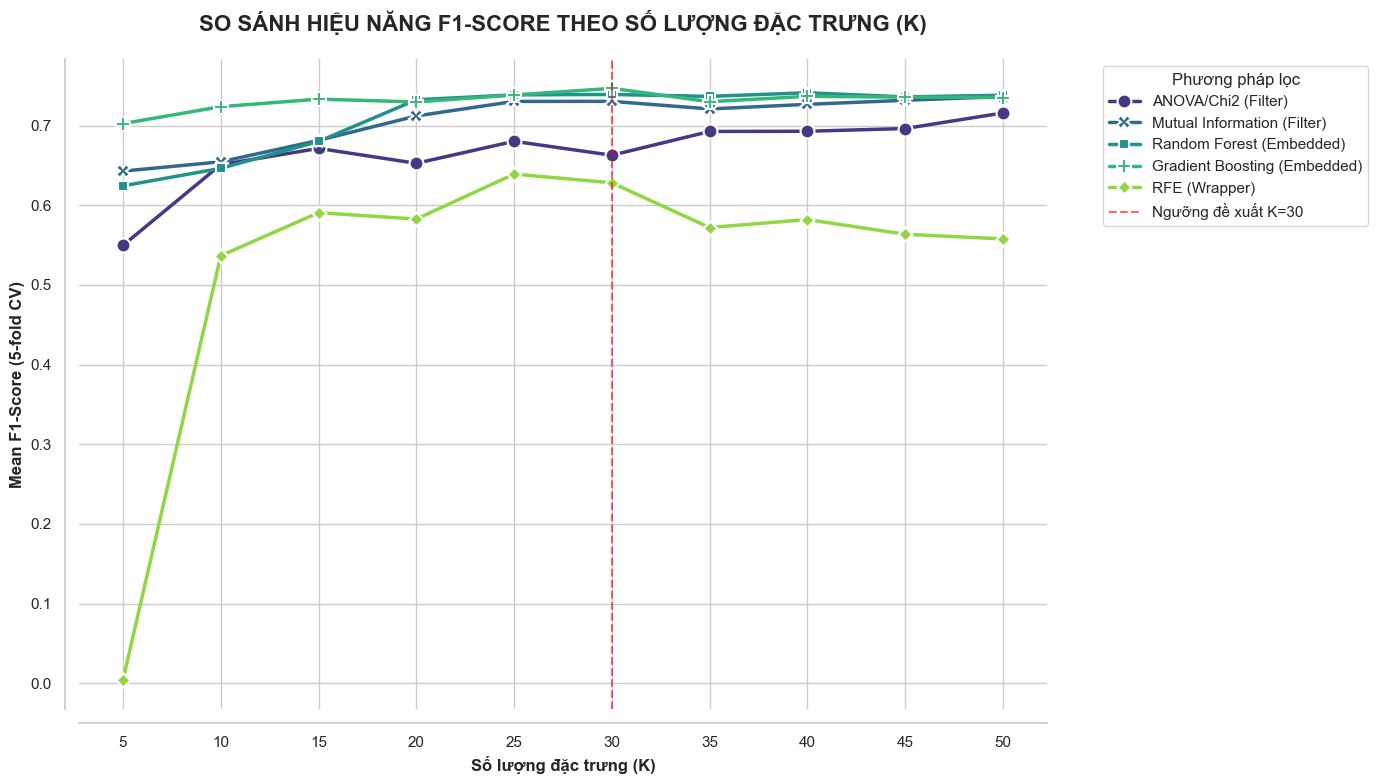

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

ax = sns.lineplot(
    data=df_perf,
    x='K', y='F1_Mean', hue='Method', style='Method',
    markers=True, markersize=10, linewidth=2.5, dashes=False, palette="viridis"
)

for line in ax.get_lines():
    line.set_markeredgecolor('white')
    line.set_markeredgewidth(1.5)

plt.title('SO SÁNH HIỆU NĂNG F1-SCORE THEO SỐ LƯỢNG ĐẶC TRƯNG (K)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số lượng đặc trưng (K)', fontsize=12, fontweight='bold')
plt.ylabel('Mean F1-Score (5-fold CV)', fontsize=12, fontweight='bold')

plt.axvline(x=30, color='red', linestyle='--', alpha=0.6, label='Ngưỡng đề xuất K=30')

plt.legend(title='Phương pháp lọc', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(k_values)
sns.despine(offset=10)
plt.tight_layout()
plt.show()

### **NHẬN XÉT:**

* **Sự áp đảo của nhóm Embedded (Mô hình nhúng):** Gradient Boosting (GB) và Random Forest (RF) thể hiện F1-score vượt trội và tính ổn định cao nhất. Nổi bật nhất là Gradient Boosting, thuật toán này đạt mức F1-score rất cao (~0.70) ngay từ khi không gian đặc trưng còn rất nhỏ ($K=5$) và liên tục dẫn đầu xu hướng xuyên suốt đồ thị. Điều này minh chứng cho khả năng nắm bắt tín hiệu phân loại cực kỳ nhạy bén của thuật toán.
* **Sự phân hóa của nhóm Filter và Wrapper:**
    * **ANOVA/Chi2 (Filter):** Đường biểu diễn biến động mạnh và bị bỏ lại phía sau. Điều này khẳng định dữ liệu tồn tại nhiều mối quan hệ phi tuyến phức tạp mà các kiểm định thống kê cơ bản không thể nắm bắt.
    * **Mutual Information (Filter):** Hoạt động rất hiệu quả, bám sát nhóm Embedded và bỏ xa ANOVA/Chi2, chứng minh được sức mạnh trong việc đánh giá tương tác phi tuyến.
    * **RFE (Wrapper):** Thể hiện khá kém ở giai đoạn đầu ($K < 20$) nhưng tăng vọt sau $K=25$. Sự sụt giảm ở các mức $K$ nhỏ cho thấy thuật toán có thể đã loại bỏ nhầm một số đặc trưng tương tác quan trọng ở những vòng lặp đào thải cuối cùng.
* **Điểm bão hòa và rủi ro quá khớp:** Tại ngưỡng $K=30$ (đường dóng đỏ), cả 3 phương pháp dẫn đầu (GB, RF, MI) đều đạt điểm bão hòa (đỉnh F1-score dao động 0.73 - 0.74) và bắt đầu đi ngang. Việc tiếp tục tăng số lượng đặc trưng lên 40 hay 50 không mang lại cải thiện hiệu năng đáng kể, ngược lại sẽ làm phình to chi phí tính toán và tăng rủi ro quá khớp (overfitting).
* **Kết luận:** Dựa trên các bằng chứng định lượng trên, nhóm quyết định chọn **tập 30 đặc trưng tốt nhất do Gradient Boosting trích xuất**. Mặc dù tại ngưỡng $K=30$, nhiều phương pháp cho kết quả xấp xỉ nhau, nhưng Gradient Boosting chứng minh được sự ổn định và tối ưu nhất trên mọi kích thước tập con.

[*] Đang chạy t-SNE trên tập mẫu 5000 dòng...


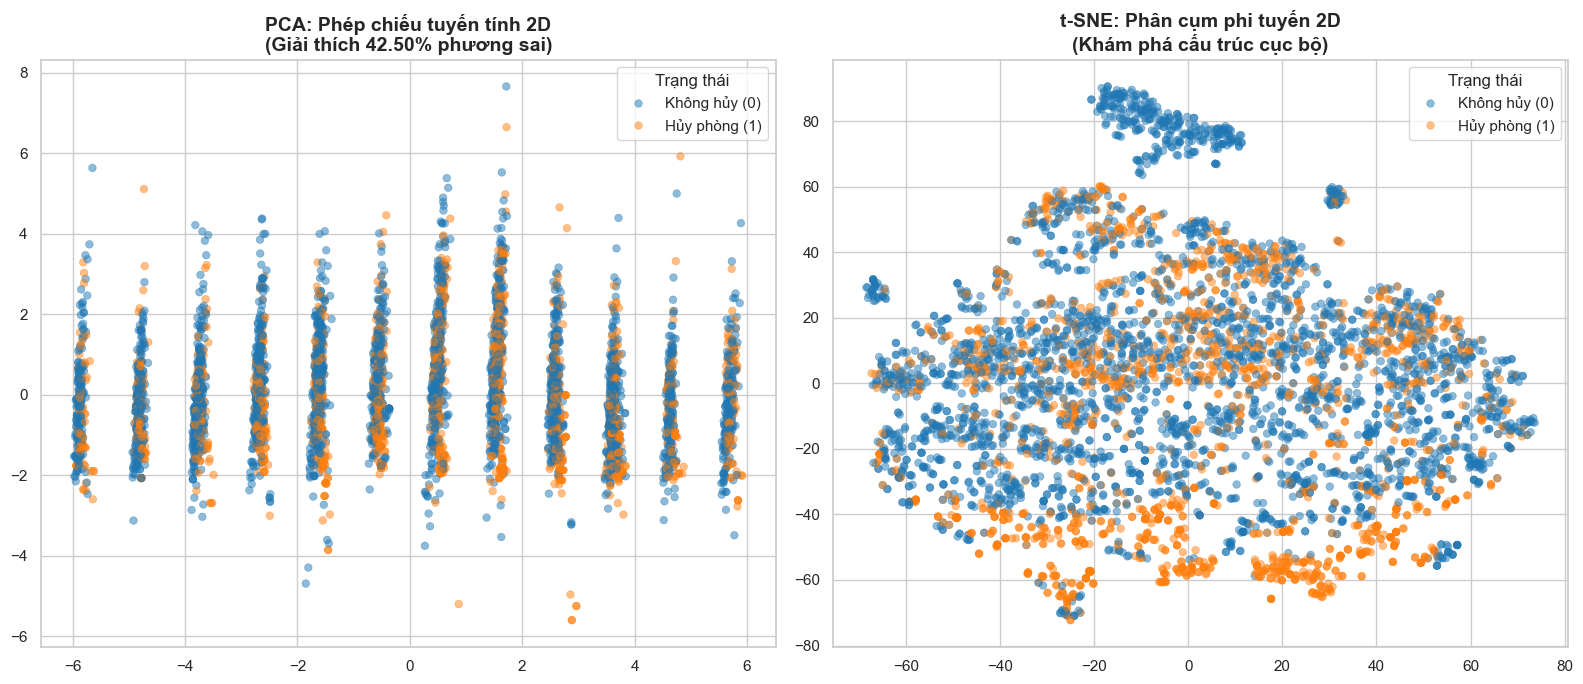

In [19]:
pca_2d = PCA(n_components=2, random_state=42)
pca_2d.fit(X_train_e)
variance_2d = pca_2d.explained_variance_ratio_.sum() * 100

# Lấy mẫu 5000 dòng dùng chung cho cả việc vẽ PCA và fit t-SNE
sample_size = 5000
X_sample = X_train_e.sample(n=sample_size, random_state=42)
y_sample = y_train.loc[X_sample.index]

X_pca_sample = pca_2d.transform(X_sample)

print(f"[*] Đang chạy t-SNE trên tập mẫu {sample_size} dòng...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, n_jobs=-1)
X_tsne_sample = tsne.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
color_palette = {0:'#1f77b4', 1: '#ff7f0e'}

sns.scatterplot(
    x=X_pca_sample[:, 0], y=X_pca_sample[:, 1],
    hue=y_sample, palette=color_palette,
    ax=axes[0], alpha=0.5, s=30, edgecolor=None
)
axes[0].set_title(f'PCA: Phép chiếu tuyến tính 2D\n(Giải thích {variance_2d:.2f}% phương sai)', fontsize=14, fontweight='bold')

# Trực quan t-SNE
sns.scatterplot(
    x=X_tsne_sample[:, 0], y=X_tsne_sample[:, 1],
    hue=y_sample, palette=color_palette,
    ax=axes[1], alpha=0.5, s=30, edgecolor=None
)
axes[1].set_title('t-SNE: Phân cụm phi tuyến 2D\n(Khám phá cấu trúc cục bộ)', fontsize=14, fontweight='bold')

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Không hủy (0)', 'Hủy phòng (1)'], title='Trạng thái', loc='best')

plt.tight_layout()
plt.show()

**NHẬN XÉT TRỰC QUAN HÓA GIẢM CHIỀU DỮ LIỆU**

* **PCA (Phép chiếu tuyến tính):** Hai thành phần chính đầu tiên chỉ giải thích được 42.50% phương sai. Trên không gian 2D, dữ liệu hình thành các dải sọc dọc (khả năng cao do sự chi phối của một vài biến phân loại hoặc rời rạc có phương sai lớn). Các điểm "Hủy phòng" (cam) và "Không hủy" (xanh) hòa trộn vào nhau hoàn toàn, không tồn tại ranh giới tuyến tính rõ rệt. Khẳng định các mô hình tuyến tính cơ bản sẽ hoạt động kém hiệu quả trên tập dữ liệu này.
* **t-SNE (Phân cụm phi tuyến):** Phép chiếu bóc tách tốt hơn cấu trúc cục bộ của dữ liệu. Mặc dù vùng trung tâm vẫn có sự chồng lấn, thuật toán đã phân tách thành công nhiều vi cụm (micro-clusters) thuần nhất ở các vùng biên.
* **Kết luận:** Sự tương phản giữa khả năng phân tách của PCA và t-SNE là minh chứng thực nghiệm cho thấy bộ dữ liệu tồn tại nhiều mối quan hệ phi tuyến phức tạp. Do đó, việc ưu tiên sử dụng các mô hình học máy phi tuyến (như Gradient Boosting, Random Forest) sẽ phù hợp và mang lại hiệu năng tối ưu hơn so với các mô hình tuyến tính truyền thống.

### **Lưu trữ dữ liệu sau tiền xử lý**

Sau khi hoàn tất việc đánh giá và chốt danh sách 30 đặc trưng tối ưu nhất ở ý (e), bộ dữ liệu này được tiến hành lưu trữ để làm đầu vào chuẩn cho giai đoạn huấn luyện.

**Chiến lược lưu trữ:**
* **Chống rò rỉ dữ liệu:** Quá trình lưu trữ được thực hiện tách biệt thành hai tập `train` và `test`. Việc cô lập tập Test từ sớm đảm bảo dữ liệu đánh giá là nguyên thủy và chưa từng bị tác động bởi các thuật toán sinh mẫu nhân tạo (SMOTE/RUS) sẽ được sử dụng ở ý (f).
* **Chuẩn hóa định dạng:** Dữ liệu được lưu dưới dạng `.csv`  trong thư mục `data/processed/`

In [20]:
best_method_df = gb_df
top_30_features = best_method_df.sort_values(by='Score', ascending=False)['Feature'].head(30).tolist()

print("DANH SÁCH 30 ĐẶC TRƯNG ĐƯỢC CHỌN:")
print(top_30_features)

df_train_final = X_train_e[top_30_features].copy()
df_train_final['is_canceled'] = y_train.values

df_test_final = X_test_e[top_30_features].copy()
df_test_final['is_canceled'] = y_test.values

output_dir = '../data/processed/'
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, 'hotel_bookings_train__processed.csv')
test_path = os.path.join(output_dir, 'hotel_bookings_test__processed.csv')

df_train_final.to_csv(train_path, index=False, encoding='utf-8-sig')
df_test_final.to_csv(test_path, index=False, encoding='utf-8-sig')

print("\n" + "="*50)
print(f"Đã lưu tập TRAIN tại: {train_path} | Kích thước: {df_train_final.shape}")
print(f"Đã lưu tập TEST tại:  {test_path} | Kích thước: {df_test_final.shape}")
print("="*50)

DANH SÁCH 30 ĐẶC TRƯNG ĐƯỢC CHỌN:
['deposit_type_Non Refund', 'lead_time', 'market_segment_Online TA', 'total_of_special_requests', 'previous_cancellations', 'required_car_parking_spaces', 'country_bin_7', 'country_bin_5', 'agent_bin_4', 'booking_changes', 'country_bin_6', 'customer_type_Transient', 'previous_bookings_not_canceled', 'adr', 'customer_type_Transient-Party', 'reserved_room_type_D', 'agent_bin_7', 'market_segment_Offline TA/TO', 'assigned_room_type_D', 'agent_bin_8', 'agent_bin_2', 'stays_in_week_nights', 'country_bin_4', 'stays_in_weekend_nights', 'adults', 'agent_bin_5', 'arrival_date_week_number', 'distribution_channel_TA/TO', 'days_in_waiting_list', 'market_segment_Groups']

Đã lưu tập TRAIN tại: ../data/processed/hotel_bookings_train__processed.csv | Kích thước: (95512, 31)
Đã lưu tập TEST tại:  ../data/processed/hotel_bookings_test__processed.csv | Kích thước: (23878, 31)


In [21]:
top_k = 30
best_features = gb_df.sort_values(by='Score', ascending=False)['Feature'].head(top_k).tolist()

X_train_final = X_train_e[best_features]
X_test_final = X_test_e[best_features]

print(f"[*] Đã trích xuất {len(best_features)} đặc trưng tối ưu nhất.")
print("-" * 45)
print(f"TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT (GRADIENT BOOSTING):")
for i, feat in enumerate(best_features[:10], 1):
    print(f" {i:2d}. {feat}")
print("-" * 45)

# Kiểm tra tỷ lệ mất cân bằng (Class Imbalance Ratio)
class_counts = y_train.value_counts()
imbalance_ratio = class_counts[1] / class_counts[0]

print("\n[*] PHÂN TÍCH PHÂN PHỐI LỚP (TẬP HUẤN LUYỆN):")
print(f" - Không hủy (0) : {class_counts[0]:,} mẫu ({class_counts[0]/len(y_train):.2%})")
print(f" - Hủy phòng (1)  : {class_counts[1]:,} mẫu ({class_counts[1]/len(y_train):.2%})")
print(f" - Tỷ lệ Minority/Majority: {imbalance_ratio:.2f}")

if imbalance_ratio < 0.8:
    print("\n=> NHẬN XÉT: Dữ liệu có dấu hiệu mất cân bằng. Cần cân nhắc áp dụng các kỹ thuật Resampling (SMOTE, Class Weights) ở pha huấn luyện (Câu f).")
else:
    print("\n=> NHẬN XÉT: Dữ liệu tương đối cân bằng, có thể tiến hành huấn luyện trực tiếp.")

[*] Đã trích xuất 30 đặc trưng tối ưu nhất.
---------------------------------------------
TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT (GRADIENT BOOSTING):
  1. deposit_type_Non Refund
  2. lead_time
  3. market_segment_Online TA
  4. total_of_special_requests
  5. previous_cancellations
  6. required_car_parking_spaces
  7. country_bin_7
  8. country_bin_5
  9. agent_bin_4
 10. booking_changes
---------------------------------------------

[*] PHÂN TÍCH PHÂN PHỐI LỚP (TẬP HUẤN LUYỆN):
 - Không hủy (0) : 60,133 mẫu (62.96%)
 - Hủy phòng (1)  : 35,379 mẫu (37.04%)
 - Tỷ lệ Minority/Majority: 0.59

=> NHẬN XÉT: Dữ liệu có dấu hiệu mất cân bằng. Cần cân nhắc áp dụng các kỹ thuật Resampling (SMOTE, Class Weights) ở pha huấn luyện (Câu f).


## f) Phát hiện và xử lý mất cân bằng lớp (Imbalanced Data Handling)

### 1. Tổng quan về tình trạng mất cân bằng
Mất cân bằng lớp xảy ra khi số lượng quan sát trong lớp mục tiêu (`is_canceled = 1`) thấp hơn nhiều so với lớp còn lại. Điều này khiến mô hình bị định kiến (bias), ưu tiên học đặc điểm của lớp đa số và làm giảm khả năng nhận diện lớp thiểu số - vốn là lớp có giá trị kinh doanh cao nhất trong bài toán này.

### 2. Các chiến lược tái cân bằng (Resampling Strategies)

Nhóm thực hiện cài đặt và so sánh 3 kỹ thuật phổ biến:

* **Random Under-sampling (RUS):**
    * **Cơ chế:** Loại bỏ ngẫu nhiên các mẫu từ lớp đa số cho đến khi tỷ lệ hai lớp cân bằng.
    * **Ưu điểm:** Giảm kích thước dữ liệu, tăng tốc độ huấn luyện.
    * **Nhược điểm:** Có thể làm mất đi các thông tin quan trọng của lớp đa số (Information loss).
* **SMOTE (Synthetic Minority Over-sampling Technique):**
    * **Cơ chế:** Thay vì sao chép các mẫu có sẵn, SMOTE tạo ra các mẫu **tổng hợp** bằng cách nội suy (interpolation) giữa một mẫu lớp thiểu số và các lân cận gần nhất ($k$-Nearest Neighbors) của nó.
    * **Ưu điểm:** Giúp mô hình mở rộng ranh giới quyết định (decision boundary) thay vì chỉ học thuộc lòng các mẫu cũ.
* **ADASYN (Adaptive Synthetic):**
    * **Cơ chế:** Tương tự SMOTE nhưng cải tiến bằng cách tập trung tạo nhiều mẫu tổng hợp hơn ở những vùng dữ liệu "khó học" (nơi lớp thiểu số bị bao vây bởi lớp đa số).
    * **Ưu điểm:** Giảm sự thiên kiến và tập trung vào việc vượt qua ranh giới quyết định phức tạp.


### 3. Tại sao **không** được resampling trước khi chia tập Train/Test?

Đây là quy tắc vàng để tránh **Rò rỉ dữ liệu (Data Leakage)**.

* **Vấn đề rò rỉ (Over-optimism):** Nếu thực hiện SMOTE trước khi chia, các mẫu tổng hợp trong tập Train có thể được tạo ra dựa trên thông tin của các mẫu mà sau này sẽ nằm trong tập Test. Khi đó, mô hình đã "nhìn thấy" trước phân phối của tập Test, dẫn đến kết quả đánh giá bị ảo (quá cao so với thực tế).
* **Tính thực tế của tập Test:** Tập Test phải đóng vai trò là "thế giới thực". Trong thực tế, dữ liệu khách đến luôn mất cân bằng. Việc tái cân bằng tập Test sẽ làm sai lệch bản chất của bài toán đánh giá, khiến các chỉ số như Precision hay Recall không còn phản ánh đúng hiệu quả vận hành của khách sạn.

> **Nguyên tắc:** Resampling là kỹ thuật hỗ trợ huấn luyện, không phải kỹ thuật xử lý dữ liệu gốc. Tập Test phải được giữ nguyên bản (chưa tái cân bằng).

### 4. Hệ thống chỉ số đánh giá (Evaluation Metrics)

Khi dữ liệu mất cân bằng, **Accuracy không còn giá trị**. Nhóm tập trung vào bộ chỉ số:

| Chỉ số | Ý nghĩa trong bài toán Hotel Booking |
| :--- | :--- |
| **Recall** | Trong số những người thực sự hủy, mô hình bắt được bao nhiêu %? (Quan trọng để tránh mất doanh thu). |
| **Precision** | Trong số những người mô hình dự báo sẽ hủy, bao nhiêu % là đúng? (Tránh làm phiền khách hàng thực). |
| **F1-macro** | Trung bình điều hòa giữa Precision và Recall cho cả 2 lớp. Giúp đánh giá sự cân bằng của mô hình. |
| **AUC-ROC** | Khả năng phân biệt giữa lớp 0 và 1 của mô hình ở mọi ngưỡng quyết định. |



In [22]:
# Thực hiện Resampling (Chỉ trên tập Train)
print("BẮT ĐẦU QUÁ TRÌNH TÁI CÂN BẰNG DỮ LIỆU (RESAMPLING)")
print("-" * 50)

samplers = {
    'Original': None,
    'RUS (Under-sampling)': RandomUnderSampler(random_state=42),
    'SMOTE (Over-sampling)': SMOTE(random_state=42),
    'ADASYN (Over-sampling)': ADASYN(random_state=42)
}

resampled_data = {}

for name, sampler in samplers.items():
    start_time = time.time()

    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train_final, y_train)
    else:
        X_res, y_res = X_train_final.copy(), y_train.copy()

    process_time = time.time() - start_time
    resampled_data[name] = {'X': X_res, 'y': y_res}

    # In báo cáo
    print(f"[{name}] Thời gian chạy: {process_time:.2f}s")
    print(f"   -> Kích thước tập Train mới: {X_res.shape}")
    print(f"   -> Phân phối lớp: 0 (Không hủy) = {sum(y_res==0)}, 1 (Hủy) = {sum(y_res==1)}\n")

BẮT ĐẦU QUÁ TRÌNH TÁI CÂN BẰNG DỮ LIỆU (RESAMPLING)
--------------------------------------------------
[Original] Thời gian chạy: 0.04s
   -> Kích thước tập Train mới: (95512, 30)
   -> Phân phối lớp: 0 (Không hủy) = 60133, 1 (Hủy) = 35379

[RUS (Under-sampling)] Thời gian chạy: 0.15s
   -> Kích thước tập Train mới: (70758, 30)
   -> Phân phối lớp: 0 (Không hủy) = 35379, 1 (Hủy) = 35379

[SMOTE (Over-sampling)] Thời gian chạy: 2.74s
   -> Kích thước tập Train mới: (120266, 30)
   -> Phân phối lớp: 0 (Không hủy) = 60133, 1 (Hủy) = 60133

[ADASYN (Over-sampling)] Thời gian chạy: 9.44s
   -> Kích thước tập Train mới: (122170, 30)
   -> Phân phối lớp: 0 (Không hủy) = 60133, 1 (Hủy) = 62037



In [23]:
print("BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH")
print("-" * 50)

evaluation_results = []

# Dùng Gradient Boosting làm mô hình đánh giá chuẩn
base_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

for name, data in resampled_data.items():
    print(f"Đang huấn luyện mô hình với dữ liệu: {name}...")
    X_train_res = data['X']
    y_train_res = data['y']

    base_model.fit(X_train_res, y_train_res)

    # Đánh giá trên tập TEST GỐC (Chưa qua resampling)
    y_pred = base_model.predict(X_test_final)
    y_proba = base_model.predict_proba(X_test_final)[:, 1] # Xác suất cho lớp 1 (Hủy phòng)

    precision_cls1 = precision_score(y_test, y_pred, pos_label=1)
    recall_cls1 = recall_score(y_test, y_pred, pos_label=1)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    auc_roc = roc_auc_score(y_test, y_proba)

    evaluation_results.append({
        'Chiến lược': name,
        'Precision (Lớp Hủy)': round(precision_cls1, 4),
        'Recall (Lớp Hủy)': round(recall_cls1, 4),
        'F1-Macro': round(f1_mac, 4),
        'AUC-ROC': round(auc_roc, 4)
    })

df_results = pd.DataFrame(evaluation_results)
display(df_results)

BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH
--------------------------------------------------
Đang huấn luyện mô hình với dữ liệu: Original...
Đang huấn luyện mô hình với dữ liệu: RUS (Under-sampling)...
Đang huấn luyện mô hình với dữ liệu: SMOTE (Over-sampling)...
Đang huấn luyện mô hình với dữ liệu: ADASYN (Over-sampling)...


,Chiến lược,Precision (Lớp Hủy),Recall (Lớp Hủy),F1-Macro,AUC-ROC
0,Original,0.8499,0.6715,0.8132,0.9185
1,RUS (Under-sampling),0.7626,0.8098,0.8265,0.9193
2,SMOTE (Over-sampling),0.7610,0.8005,0.8228,0.9162
3,ADASYN (Over-sampling),0.6929,0.8744,0.8048,0.9140


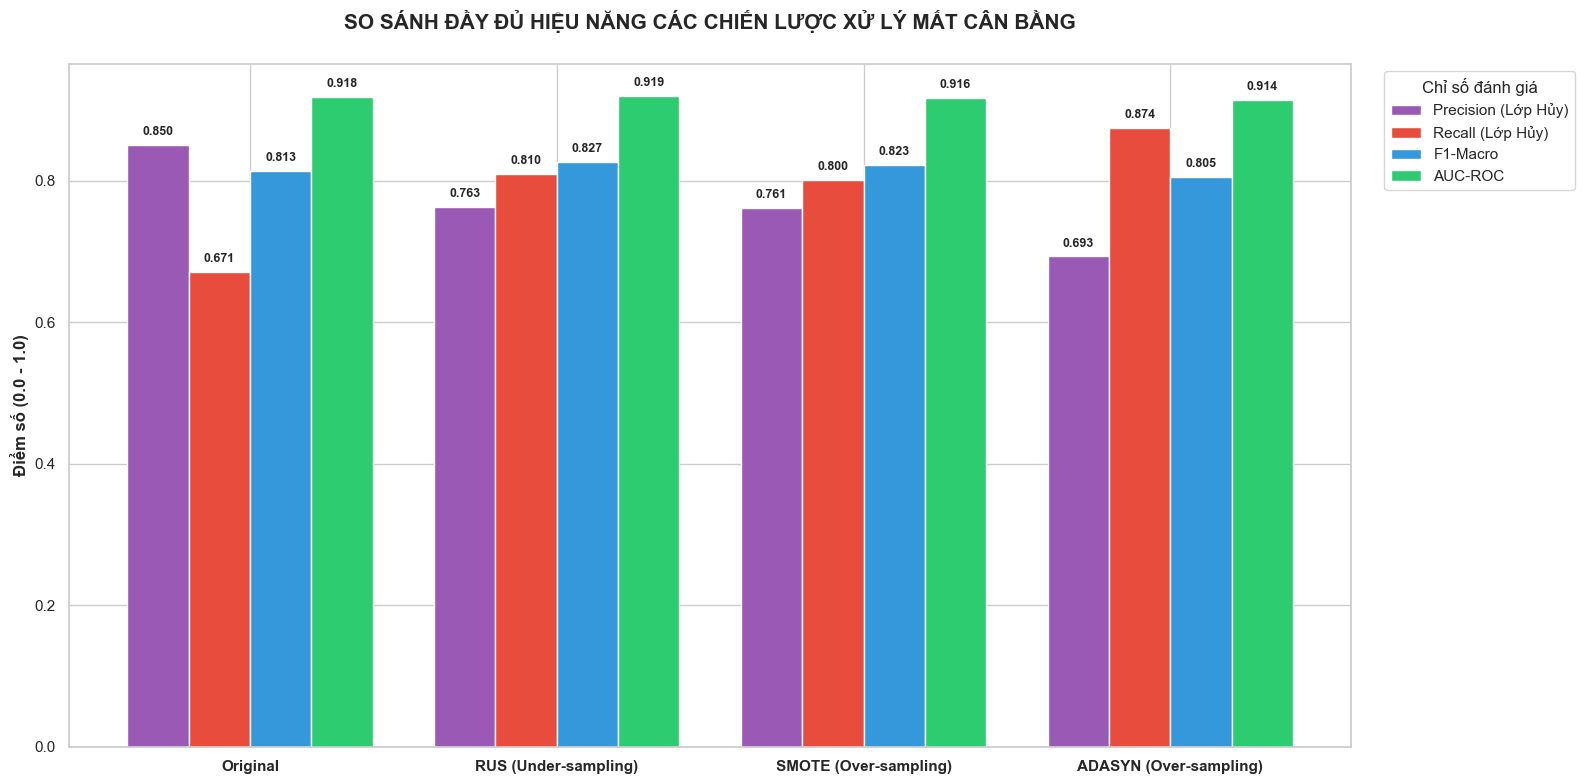

In [24]:
sns.set_theme(style="whitegrid")
strategies = df_results['Chiến lược']

precision_scores = df_results['Precision (Lớp Hủy)']
recall_scores = df_results['Recall (Lớp Hủy)']
f1_macro_scores = df_results['F1-Macro']
auc_roc_scores = df_results['AUC-ROC']

x = np.arange(len(strategies))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 8))

rects1 = ax.bar(x - 1.5*width, precision_scores, width, label='Precision (Lớp Hủy)', color='#9b59b6')
rects2 = ax.bar(x - 0.5*width, recall_scores, width, label='Recall (Lớp Hủy)', color='#e74c3c')
rects3 = ax.bar(x + 0.5*width, f1_macro_scores, width, label='F1-Macro', color='#3498db')
rects4 = ax.bar(x + 1.5*width, auc_roc_scores, width, label='AUC-ROC', color='#2ecc71')

ax.set_ylabel('Điểm số (0.0 - 1.0)', fontsize=12, fontweight='bold')
ax.set_title('SO SÁNH ĐẦY ĐỦ HIỆU NĂNG CÁC CHIẾN LƯỢC XỬ LÝ MẤT CÂN BẰNG',
             fontsize=15, fontweight='bold', pad=25)
ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=11, fontweight='bold')
ax.legend(title="Chỉ số đánh giá", title_fontsize='12',
          loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11, frameon=True)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.show()

### **PHÂN TÍCH HIỆU NĂNG CÁC CHIẾN LƯỢC TÁI CÂN BẰNG**

Dựa trên kết quả thực nghiệm trực quan từ biểu đồ với 4 chỉ số đo lường, có thể thấy rõ sự phân hóa về chiến thuật của các mô hình:

* **Sự đánh đổi giữa Precision và Recall:**
    * **Mô hình gốc (Original):** Đạt **Precision cao nhất (0.850)** nhưng **Recall lại thấp nhất (0.671)**. Điều này cho thấy mô hình ban đầu rất "thận trọng": chỉ dự báo hủy khi cực kỳ chắc chắn, dẫn đến việc bỏ sót khoảng **32.9%** lượng khách thực tế sẽ hủy phòng.
    * **Chiến lược ADASYN:** Thể hiện thái độ ngược lại hoàn toàn khi đẩy **Recall vọt lên 0.874** nhưng đánh đổi bằng việc **Precision sụt giảm mạnh (0.693)**. Việc tạo quá nhiều mẫu ảo ở vùng biên khiến mô hình bị nhiễu, dẫn đến tỷ lệ báo động giả cao (dự báo sai khách không hủy thành hủy).
* **Điểm cân bằng tối ưu (RUS và SMOTE):**
    * Cả hai phương pháp này đều thiết lập được sự cân bằng tốt nhất giữa việc "bắt đúng" và "không bắt nhầm". **RUS (Under-sampling)** đạt **F1-Macro đỉnh (0.827)**, giúp cải thiện đáng kể Recall lên **0.810** trong khi vẫn duy trì Precision ở mức tốt (**0.763**).
    * **SMOTE** bám sát nút với các chỉ số tương đương (F1-Macro đạt 0.823, Recall 0.800), khẳng định đây là hai lựa chọn bền vững cho việc phân loại.
* **Tính ổn định của AUC-ROC:** Chỉ số này duy trì ổn định ở mức rất cao (**0.914 - 0.919**) trên tất cả các kịch bản. Điều này minh chứng rằng tập đặc trưng đã chọn có năng lực phân tách lớp rất mạnh mẽ; việc tái cân bằng chủ yếu tác động đến việc thay đổi ngưỡng quyết định (threshold) để ưu tiên lớp thiểu số.


### **Kết luận**

Dựa trên bằng chứng định lượng, chiến lược **RUS (Random Under-sampling)** được lựa chọn làm đầu vào cho pha tinh chỉnh mô hình cuối cùng. Chiến lược này không chỉ mang lại **F1-Macro cao nhất** mà còn giúp giảm kích thước tập dữ liệu huấn luyện.